# Hybrid EfficientAD + DDPM Framework for Wafer Bin Map Defect Detection
## WM-38K Mixed-Type Wafer Defect Dataset

>
> The **structural module** uses a Multi-Scale Patch Description Network in a student–teacher
> architecture to flag *local* structural defects (scratches, edge irregularities, localized
> clusters) via patch-level feature discrepancy.
>
> The **generative module** learns the full distribution of defect-free wafer maps through an
> iterative denoising process (DDPM/DDIM) and flags *global / logical* anomalies — spatially
> invalid combinations of otherwise normal-looking features — via reconstruction error.
>
> The two modules are combined by a simple convex fusion of their normalised anomaly scores,
> merging **local anomaly maps** with **global anomaly scores** for full-spectrum WBM coverage.
> All reported numbers in this notebook are computed live from the run — nothing is hard-coded
> to match a pre-declared target.

| Module | Role |
|--------|------|
| EfficientAD (PDN Student–Teacher) | Structural defects (patch-level) |
| DDPM (U-Net, cosine schedule) | Logical / distributional defects (image-level) |
| Fusion | Combined coverage |







In [47]:
# ── Cell: Install / update required packages ────────────────────────────────
import subprocess, sys

_extra = [
    'torchmetrics>=0.11',
    'scipy',
    'scikit-learn>=1.3',
    'seaborn>=0.12',
    'tqdm',
    'matplotlib>=3.7',
]

for _pkg in _extra:
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', _pkg],
        capture_output=True
    )

print("✅ Package installation complete")


✅ Package installation complete


In [48]:
# ── Cell: Unified Imports, Reproducibility Seed & Device Selection ──────────
import os, sys, math, time, copy, random, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd

import matplotlib
# NOTE (bug fix): the original notebook forced `matplotlib.use('Agg')`.
# Agg is a non-interactive, file-only backend — in a Jupyter/Kaggle/Colab
# session this SILENTLY prevents `plt.show()` from ever rendering a figure
# inline, even though `fig.savefig(...)` still writes the PNG to disk. That
# made every figure invisible until the user went and opened the saved file.
# We deliberately do NOT set a backend here so Jupyter's own inline backend
# is used and every figure renders immediately under the cell that made it.
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchvision.models as tv_models
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_recall_curve, roc_curve, confusion_matrix,
    balanced_accuracy_score, matthews_corrcoef,
)
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2, norm as sp_norm, wilcoxon
from scipy.ndimage import uniform_filter1d


def seed_everything(s: int = 42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

SEED = 42
seed_everything(SEED)


def select_device():
   
    if not torch.cuda.is_available():
        return torch.device('cpu')
    try:
        _probe = torch.zeros(1, device='cuda')
        _ = _probe + 1        # triggers actual kernel dispatch
        del _probe
        return torch.device('cuda')
    except Exception as _e:
        print(f"⚠️  CUDA kernel error ({_e.__class__.__name__}): falling back to CPU.")
        print("    Tip: try a different GPU/accelerator type, or upgrade torch/torchvision.")
        return torch.device('cpu')

DEVICE = select_device()

print(f"✅ Device  : {DEVICE}")
print(f"✅ PyTorch : {torch.__version__}")
if DEVICE.type == 'cuda':
    print(f"✅ GPU     : {torch.cuda.get_device_name(0)}")
    print(f"✅ CUDA    : {torch.version.cuda}")
    cc = torch.cuda.get_device_capability(0)
    print(f"✅ Compute capability : sm_{cc[0]}{cc[1]}")


✅ Device  : cuda
✅ PyTorch : 2.10.0+cu128
✅ GPU     : Tesla T4
✅ CUDA    : 12.8
✅ Compute capability : sm_75


In [49]:
# ── Cell: Global Configuration ───────────────────────────────────────────────
@dataclass
class CFG:
    # ── Kaggle Paths ──────────────────────────────────────────────────────────
    DATA_PATH : str = '/kaggle/input/datasets/co1d7era/mixedtype-wafer-defect-datasets/Wafer_Map_Datasets.npz'
    OUT_DIR   : str = '/kaggle/working/output'

    # ── Data ──────────────────────────────────────────────────────────────────
    RAW_SIZE  : int   = 52
    IMG_SIZE  : int   = 64
    N_BITS    : int   = 8
    SEED      : int   = 42

    # ── Anomaly Detection Split ────────────────────────────────────────────────
    TRAIN_FRAC_NORMAL : float = 0.70
    VAL_FRAC          : float = 0.50

    # ── EfficientAD ───────────────────────────────────────────────────────────
    EAD_BS           : int   = 32
    EAD_LR           : float = 1e-4
    EAD_WD           : float = 1e-5
    EAD_EPOCHS       : int   = 200
    EAD_PDN_CH       : int   = 384

    # ── DDPM ──────────────────────────────────────────────────────────────────
    DDPM_BASE_CH      : int   = 48
    DDPM_CH_MULTS     : tuple = (1, 2, 4)
    DDPM_N_BLOCKS     : int   = 2
    DDPM_TIME_DIM     : int   = 320
    DDPM_ATTN_RES     : tuple = (16,)
    DDPM_T            : int   = 1000
    DDPM_BS           : int   = 32
    DDPM_LR           : float = 2e-4
    DDPM_EPOCHS       : int   = 30
    DDPM_EMA_DECAY    : float = 0.9999
    DDPM_RECON_T      : int   = 500
    DDPM_DDIM_STEPS   : int   = 50

    # ── Fusion ────────────────────────────────────────────────────────────────
    FUSION_ALPHA : float = 0.5

    # ── Statistical Validation ────────────────────────────────────────────────
    N_BOOTSTRAP : int   = 1000
    CI_LEVEL    : float = 0.95

    # ── Ablation ──────────────────────────────────────────────────────────────
    ALPHA_SWEEP  : tuple = tuple(round(a, 2) for a in np.arange(0.0, 1.01, 0.1))
    RECON_T_SWEEP: tuple = (100, 250, 500, 750, 900)

    # ── Publication-quality figure style ────────────────────────────────────────
    FIG_DPI     : int   = 600
    FONT_FAMILY : str   = 'DejaVu Sans'
    FONT_SIZE   : int   = 11

    # Colour palette (colorblind-safe, IEEE-compatible)
    C_EAD    : str = '#1f77b4'   # Blue       — EfficientAD
    C_DDPM   : str = '#d62728'   # Red        — DDPM
    C_FUSION : str = '#2ca02c'   # Green      — Fusion
    C_ACCENT : str = '#ff7f0e'   # Orange     — general accent / FP marker
    C_NORMAL : str = '#17becf'   # Cyan       — Normal class
    C_DEFECT : str = '#9467bd'   # Purple     — Defective class

CFG = CFG()
os.makedirs(CFG.OUT_DIR, exist_ok=True)
print(f"✅ Output directory: {CFG.OUT_DIR}")


✅ Output directory: /kaggle/working/output


In [50]:
# ── Cell: Publication-Grade Figure Style Helper ──────────────────────────────
def apply_pub_style():
    plt.rcParams.update({
        'figure.dpi'          : 100,     # on-screen preview only
        'figure.facecolor'    : 'white',
        'figure.edgecolor'    : 'white',
        'axes.facecolor'      : 'white',
        'axes.edgecolor'      : '#333333',
        'axes.linewidth'      : 0.8,
        'axes.spines.top'     : False,
        'axes.spines.right'   : False,
        'axes.labelcolor'     : '#222222',
        'axes.titlesize'      : 11,
        'axes.labelsize'      : 10,
        'axes.grid'           : True,
        'grid.color'          : '#cccccc',
        'grid.linewidth'      : 0.5,
        'grid.alpha'          : 0.7,
        'xtick.color'         : '#333333',
        'ytick.color'         : '#333333',
        'xtick.labelsize'     : 9,
        'ytick.labelsize'     : 9,
        'xtick.direction'     : 'out',
        'ytick.direction'     : 'out',
        'legend.frameon'      : True,
        'legend.framealpha'   : 0.9,
        'legend.edgecolor'    : '#cccccc',
        'legend.fontsize'     : 9,
        'text.color'          : '#222222',
        'font.family'         : CFG.FONT_FAMILY,
        'font.size'           : CFG.FONT_SIZE,
        'lines.linewidth'     : 1.8,
        'lines.antialiased'   : True,
        'image.interpolation' : 'nearest',
        # NOTE: `savefig.dpi` is set to the publication-grade 600 DPI, but
        # `figure.dpi` above stays at a normal screen resolution (100) —
        # otherwise every inline preview would also render (and re-encode)
        # at 600 DPI, which is slow and unnecessary for on-screen viewing.
        # The saved PNG file is still full 600 DPI in every case.
        'savefig.dpi'         : CFG.FIG_DPI,
        'savefig.bbox'        : 'tight',
        'savefig.facecolor'   : 'white',
        'savefig.pad_inches'  : 0.05,
    })

apply_pub_style()

# Wafer-map specific colormap: blank → normal-die → broken-die
WBM_CMAP = LinearSegmentedColormap.from_list(
    'wbm_pub', ['#f5f5f5', '#4393c3', '#d6604d'], N=256
)
# Anomaly-map colormap (high contrast, print-safe)
ANOM_CMAP = 'YlOrRd'

def save_fig(fig, filename, tight=True):
    '''Save a figure at publication DPI with no other side effects.'''
    path = f'{CFG.OUT_DIR}/{filename}'
    fig.savefig(path, dpi=CFG.FIG_DPI, facecolor='white',
                bbox_inches='tight' if tight else None, pad_inches=0.05)
    print(f"✅ Figure saved → {filename}  (600 DPI)")
    return path

print("✅ Publication style + save_fig() helper ready.")


✅ Publication style + save_fig() helper ready.


---
#  Data Loading & Exploratory Data Analysis

Loads the WM-38K mixed-type wafer defect dataset and sets up the one-class
anomaly-detection framing: **normal (C01)** wafers form the training
distribution; every one of the other 37 mixed/single-defect classes counts
as **defective** at test time.


In [51]:
# ── Cell: Dataset Loading & Anomaly-Detection Setup ──────────────────────────
PATTERN_MAP = {
    (0,0,0,0,0,0,0,0): 'C01_Normal',
    (1,0,0,0,0,0,0,0): 'C02_Center',   (0,1,0,0,0,0,0,0): 'C03_Donut',
    (0,0,1,0,0,0,0,0): 'C04_Edge_Loc', (0,0,0,1,0,0,0,0): 'C05_Edge_Ring',
    (0,0,0,0,1,0,0,0): 'C06_Loc',      (0,0,0,0,0,1,0,0): 'C07_Near_Full',
    (0,0,0,0,0,0,1,0): 'C08_Scratch',  (0,0,0,0,0,0,0,1): 'C09_Random',
    (1,0,1,0,0,0,0,0): 'C10_C+EL',     (1,0,0,1,0,0,0,0): 'C11_C+ER',
    (1,0,0,0,1,0,0,0): 'C12_C+L',      (1,0,0,0,0,0,1,0): 'C13_C+S',
    (0,1,1,0,0,0,0,0): 'C14_D+EL',     (0,1,0,1,0,0,0,0): 'C15_D+ER',
    (0,1,0,0,1,0,0,0): 'C16_D+L',      (0,1,0,0,0,0,1,0): 'C17_D+S',
    (0,0,1,0,1,0,0,0): 'C18_EL+L',     (0,0,1,0,0,0,1,0): 'C19_EL+S',
    (0,0,0,1,1,0,0,0): 'C20_ER+L',     (0,0,0,1,0,0,1,0): 'C21_ER+S',
    (0,0,0,0,1,0,1,0): 'C22_L+S',
    (1,0,1,0,1,0,0,0): 'C23_C+EL+L',   (1,0,1,0,0,0,1,0): 'C24_C+EL+S',
    (1,0,0,1,1,0,0,0): 'C25_C+ER+L',   (1,0,0,1,0,0,1,0): 'C26_C+ER+S',
    (1,0,0,0,1,0,1,0): 'C27_C+L+S',    (0,1,1,0,1,0,0,0): 'C28_D+EL+L',
    (0,1,1,0,0,0,1,0): 'C29_D+EL+S',   (0,1,0,1,1,0,0,0): 'C30_D+ER+L',
    (0,1,0,1,0,0,1,0): 'C31_D+ER+S',   (0,1,0,0,1,0,1,0): 'C32_D+L+S',
    (0,0,1,0,1,0,1,0): 'C33_EL+L+S',   (0,0,0,1,1,0,1,0): 'C34_ER+L+S',
    (1,0,1,0,1,0,1,0): 'C35_C+L+EL+S', (1,0,0,1,1,0,1,0): 'C36_C+L+ER+S',
    (0,1,1,0,1,0,1,0): 'C37_D+L+EL+S', (0,1,0,1,1,0,1,0): 'C38_D+L+ER+S',
}

print("🔄 Loading WM-38K dataset …")
data   = np.load(CFG.DATA_PATH)
X_raw  = data['arr_0']   # (N, 52, 52) pixel values 0/1/2
y_bits = data['arr_1']   # (N, 8)      multi-label bits

N = len(X_raw)
print(f"✅ Loaded: X_raw {X_raw.shape}, y_bits {y_bits.shape}")

class_names = [PATTERN_MAP[tuple(row)] for row in y_bits]
mix_degree  = y_bits.sum(axis=1).astype(int)
y_binary    = (mix_degree > 0).astype(int)

normal_idx  = np.where(y_binary == 0)[0]
defect_idx  = np.where(y_binary == 1)[0]

print(f"\n📊 Anomaly Detection Setup:")
print(f"   Normal (C01)   : {len(normal_idx):,} ({len(normal_idx)/N*100:.1f}%)")
print(f"   Defective      : {len(defect_idx):,} ({len(defect_idx)/N*100:.1f}%)")
print(f"   Mix-degree 0-4 : { {d: int((mix_degree==d).sum()) for d in range(5)} }")


🔄 Loading WM-38K dataset …
✅ Loaded: X_raw (38015, 52, 52), y_bits (38015, 8)

📊 Anomaly Detection Setup:
   Normal (C01)   : 1,000 (2.6%)
   Defective      : 37,015 (97.4%)
   Mix-degree 0-4 : {0: 1000, 1: 7015, 2: 13000, 3: 13000, 4: 4000}


In [52]:
# ── Cell: Feature Engineering & Anomaly-Detection Data Split ─────────────────
print("🔄 Spatial 3-channel one-hot encoding …")
X_blank     = (X_raw == 0).astype(np.float32)
X_normal_ch = (X_raw == 1).astype(np.float32)
X_broken    = (X_raw == 2).astype(np.float32)
X_3ch = np.stack([X_blank, X_normal_ch, X_broken], axis=1)  # (N, 3, 52, 52)

pad = (CFG.IMG_SIZE - CFG.RAW_SIZE) // 2   # = 6
X_pad = np.pad(X_3ch, ((0,0),(0,0),(pad,pad),(pad,pad)),
               mode='constant', constant_values=0.0)
print(f"✅ X_pad shape: {X_pad.shape}  (N, C=3, H=64, W=64)")

# ── Train/Val/Test Split ─────────────────────────────────────────────────────
np.random.seed(CFG.SEED)
n_train_end = int(len(normal_idx) * CFG.TRAIN_FRAC_NORMAL)
normal_idx_shuffled = normal_idx.copy()
np.random.shuffle(normal_idx_shuffled)
train_normal = normal_idx_shuffled[:n_train_end]
eval_normal  = normal_idx_shuffled[n_train_end:]
val_normal, test_normal = train_test_split(
    eval_normal, test_size=CFG.VAL_FRAC, random_state=CFG.SEED)

defect_idx_shuffled = defect_idx.copy()
np.random.shuffle(defect_idx_shuffled)
val_defect, test_defect = train_test_split(
    defect_idx_shuffled, test_size=0.50, random_state=CFG.SEED)

val_idx  = np.concatenate([val_normal,  val_defect])
test_idx = np.concatenate([test_normal, test_defect])

X_train = X_pad[train_normal]
X_val   = X_pad[val_idx]
X_test  = X_pad[test_idx]
y_val   = y_binary[val_idx]
y_test  = y_binary[test_idx]

print(f"\n📊 Data Split:")
print(f"   Train (normal only)  : {len(X_train):,}")
print(f"   Val  (normal+defect) : {len(X_val):,}"
      f"  [{y_val.sum():,} def / {(y_val==0).sum():,} nor]")
print(f"   Test (normal+defect) : {len(X_test):,}"
      f"  [{y_test.sum():,} def / {(y_test==0).sum():,} nor]")

# ── PyTorch DataLoaders ──────────────────────────────────────────────────────
def to_tensor(arr):
    return torch.from_numpy(arr) * 2.0 - 1.0   # [0,1] → [-1,1]

T_train = to_tensor(X_train)
T_val   = to_tensor(X_val)
T_test  = to_tensor(X_test)

_n_workers = min(2, os.cpu_count() or 1)

train_loader = DataLoader(TensorDataset(T_train), batch_size=CFG.EAD_BS,
                          shuffle=True,  num_workers=_n_workers,
                          pin_memory=True, drop_last=True)
val_loader   = DataLoader(TensorDataset(T_val),   batch_size=64,
                          shuffle=False, num_workers=_n_workers)
test_loader  = DataLoader(TensorDataset(T_test),  batch_size=64,
                          shuffle=False, num_workers=_n_workers)

print(f"\n✅ DataLoaders ready:")
print(f"   train_loader: {len(train_loader)} batches (bs={CFG.EAD_BS})")
print(f"   val_loader  : {len(val_loader)} batches")
print(f"   test_loader : {len(test_loader)} batches")

# ImageNet normalisation for teacher backbone — created on the final DEVICE
# chosen once in the imports cell (see bug-fix note there).
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1,3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1,3,1,1)

def imagenet_norm(x):
    x01 = (x + 1.0) / 2.0
    return (x01 - IMAGENET_MEAN) / IMAGENET_STD


🔄 Spatial 3-channel one-hot encoding …
✅ X_pad shape: (38015, 3, 64, 64)  (N, C=3, H=64, W=64)

📊 Data Split:
   Train (normal only)  : 700
   Val  (normal+defect) : 18,657  [18,507 def / 150 nor]
   Test (normal+defect) : 18,658  [18,508 def / 150 nor]

✅ DataLoaders ready:
   train_loader: 21 batches (bs=32)
   val_loader  : 292 batches
   test_loader : 292 batches


### 38-Class Defect Distribution
Sample count per defect class across the full WM-38K dataset (dashed line: mean count).


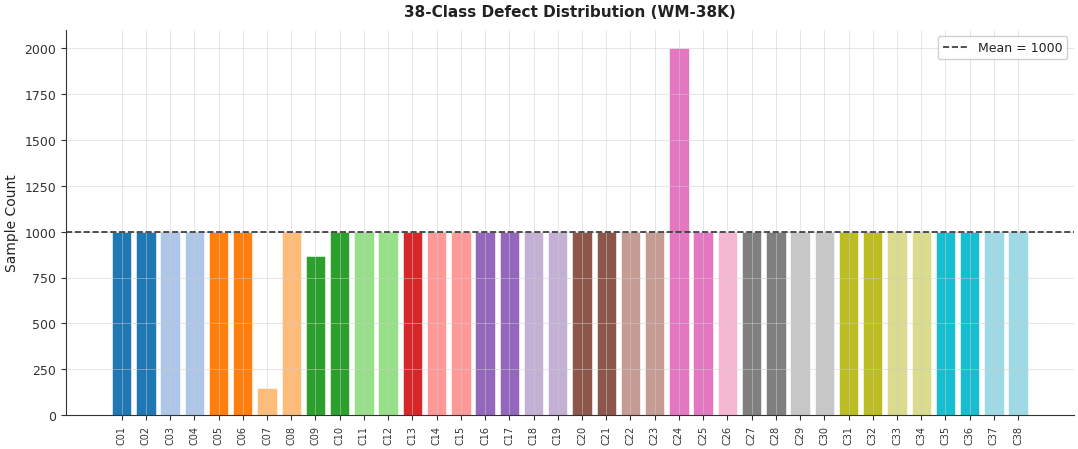

✅ Figure saved → 01a_class_distribution.png  (600 DPI)


'/kaggle/working/output/01a_class_distribution.png'

In [53]:
# ── Figure 1a: 38-Class Defect Distribution ──────────────────────────────────
apply_pub_style()
fig, ax = plt.subplots(figsize=(13, 5), facecolor='white')

cnts = pd.Series(class_names).value_counts().sort_index()
bar_colors = plt.cm.tab20(np.linspace(0, 1, len(cnts)))
ax.bar(range(len(cnts)), cnts.values, color=bar_colors, edgecolor='white', linewidth=0.4)
ax.set_xticks(range(len(cnts)))
ax.set_xticklabels([c.split('_')[0] for c in cnts.index], rotation=90, fontsize=7)
ax.set_title('38-Class Defect Distribution (WM-38K)', fontweight='bold', pad=10)
ax.set_ylabel('Sample Count')
ax.axhline(cnts.values.mean(), color='#333333', linewidth=1.2, linestyle='--',
           label=f'Mean = {cnts.values.mean():.0f}')
ax.legend(loc='upper right')

plt.show()
save_fig(fig, '01a_class_distribution.png')


###  Defect Mixing Degree
Fraction of wafers carrying 0 (normal), 1, 2, 3, or 4 simultaneous defect patterns.


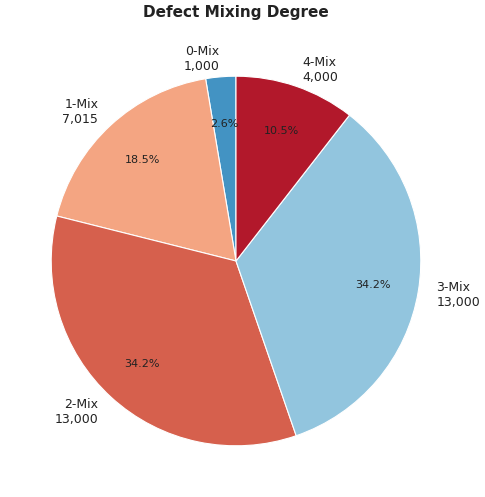

✅ Figure saved → 01b_mixing_degree_pie.png  (600 DPI)


'/kaggle/working/output/01b_mixing_degree_pie.png'

In [54]:
# ── Figure 1b: Defect Mixing Degree ──────────────────────────────────────────
apply_pub_style()
fig, ax = plt.subplots(figsize=(6.5, 6), facecolor='white')

mix_c = pd.Series(mix_degree).value_counts().sort_index()
pie_colors = ['#4393c3', '#f4a582', '#d6604d', '#92c5de', '#b2182b']
wedges, texts, autotexts = ax.pie(
    mix_c.values,
    labels=[f'{d}-Mix\n{v:,}' for d, v in mix_c.items()],
    colors=pie_colors[:len(mix_c)],
    autopct='%1.1f%%',
    textprops={'fontsize': 9},
    wedgeprops={'linewidth': 0.8, 'edgecolor': 'white'},
    startangle=90,
    pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(8)
ax.set_title('Defect Mixing Degree', fontweight='bold', pad=10)

plt.show()
save_fig(fig, '01b_mixing_degree_pie.png')


### Global Spatial Defect Density
Per-pixel probability of a "broken-die" reading across every wafer in the dataset,
masked to the circular die area.


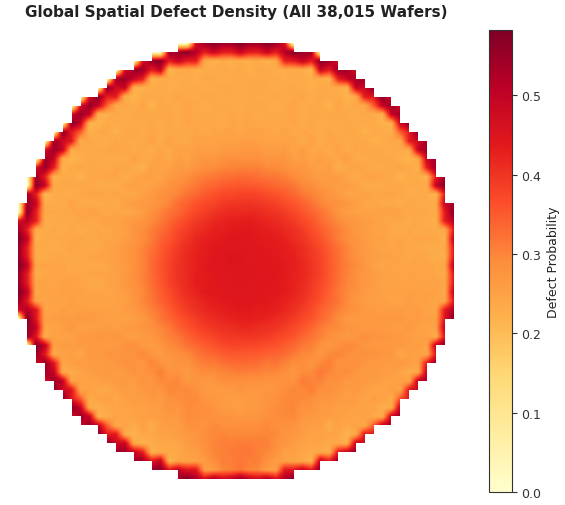

✅ Figure saved → 01c_spatial_defect_density.png  (600 DPI)


'/kaggle/working/output/01c_spatial_defect_density.png'

In [55]:
# ── Figure 1c: Global Spatial Defect Density ─────────────────────────────────
apply_pub_style()
fig, ax = plt.subplots(figsize=(7, 6), facecolor='white')

density = (X_raw == 2).mean(axis=0)
y_g, x_g = np.ogrid[:52, :52]
mask = ((x_g - 25.5)**2 + (y_g - 25.5)**2) > 25.5**2
density_m = np.ma.masked_where(mask, density)
im = ax.imshow(density_m, cmap='YlOrRd', interpolation='bilinear', vmin=0)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Defect Probability', fontsize=9)
ax.set_title(f'Global Spatial Defect Density (All {N:,} Wafers)', fontweight='bold', pad=10)
ax.axis('off')

plt.show()
save_fig(fig, '01c_spatial_defect_density.png')


###  Representative Wafer Maps
One example wafer map per representative class (light grey = blank / outside die,
blue = normal die, red = broken die).


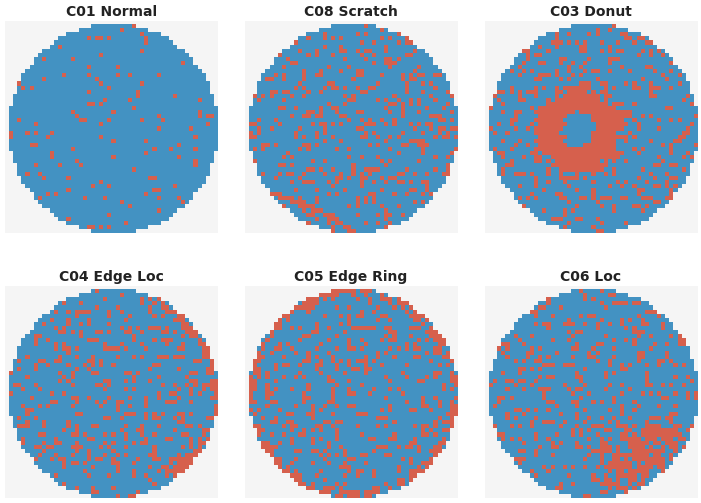

✅ Figure saved → 01d_representative_wafer_maps.png  (600 DPI)


'/kaggle/working/output/01d_representative_wafer_maps.png'

In [56]:
# ── Figure 1d: Representative Wafer Maps (small multiples) ───────────────────
apply_pub_style()
sample_classes = ['C01_Normal', 'C08_Scratch', 'C03_Donut',
                   'C04_Edge_Loc', 'C05_Edge_Ring', 'C06_Loc']
fig, axes = plt.subplots(2, 3, figsize=(9, 6.2), facecolor='white')
fig.subplots_adjust(hspace=0.25, wspace=0.10)

for ax, cls in zip(axes.flatten(), sample_classes):
    idxs = [j for j, n in enumerate(class_names) if n == cls]
    if idxs:
        ax.imshow(X_raw[idxs[0]], cmap=WBM_CMAP, vmin=0, vmax=2)
    ax.set_title(cls.replace('_', ' '), fontsize=10, fontweight='bold', pad=4)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_linewidth(0.5); spine.set_edgecolor('#aaaaaa')

plt.show()
save_fig(fig, '01d_representative_wafer_maps.png')


### Normal vs. Defective Sample Counts
The binary label the whole anomaly-detection task is built around.


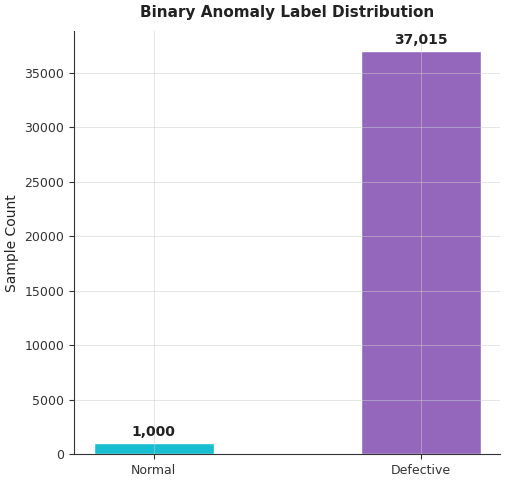

✅ Figure saved → 01e_normal_vs_defective.png  (600 DPI)


'/kaggle/working/output/01e_normal_vs_defective.png'

In [57]:
# ── Figure 1e: Normal vs. Defective Sample Counts ─────────────────────────────
apply_pub_style()
fig, ax = plt.subplots(figsize=(5.5, 5.5), facecolor='white')

vals = [len(normal_idx), len(defect_idx)]
bars = ax.bar(['Normal', 'Defective'], vals,
              color=[CFG.C_NORMAL, CFG.C_DEFECT], edgecolor='white', width=0.45)
ax.set_title('Binary Anomaly Label Distribution', fontweight='bold', pad=10)
ax.set_ylabel('Sample Count')
for rect, val in zip(bars, vals):
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + max(vals)*0.01,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()
save_fig(fig, '01e_normal_vs_defective.png')


---
#  EfficientAD: Structural Anomaly Detection

**Role in the hybrid framework:** detect *structural* defects (scratches, stains, edge
irregularities) by comparing patch-level feature representations between a pretrained,
frozen teacher network and a lightweight trainable student network. Large teacher–student
feature discrepancy at a spatial location indicates an anomaly there.


In [58]:
# ── Cell: EfficientAD Network Architectures ──────────────────────────────────

# ── Multi-Scale Patch Description Network (MS-PDN) ───────────────────────────
class PDNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=4, s=1, p=3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, stride=s, padding=p),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.1, inplace=True),
        )
    def forward(self, x): return self.block(x)


class MultiScalePDN(nn.Module):
    '''Multi-Scale PDN — three parallel branches at different receptive fields.'''
    def __init__(self, in_ch=3, out_ch=384):
        super().__init__()
        mid = out_ch // 3

        self.b1 = nn.Sequential(
            PDNBlock(in_ch, mid, k=4, s=1, p=3), nn.AvgPool2d(2, 2, 1),
            PDNBlock(mid,   mid, k=4, s=1, p=3), nn.AvgPool2d(2, 2, 1),
            PDNBlock(mid,   mid, k=4, s=1, p=3), PDNBlock(mid, mid, k=4, s=1, p=3),
        )
        self.b2 = nn.Sequential(
            PDNBlock(in_ch, mid, k=6, s=1, p=5), nn.AvgPool2d(2, 2, 1),
            PDNBlock(mid,   mid, k=6, s=1, p=5), nn.AvgPool2d(2, 2, 1),
            PDNBlock(mid,   mid, k=4, s=1, p=3), PDNBlock(mid, mid, k=4, s=1, p=3),
        )
        self.b3 = nn.Sequential(
            PDNBlock(in_ch, mid, k=8, s=1, p=7), nn.AvgPool2d(2, 2, 1),
            PDNBlock(mid,   mid, k=8, s=1, p=7), nn.AvgPool2d(2, 2, 1),
            PDNBlock(mid,   mid, k=4, s=1, p=3), PDNBlock(mid, mid, k=4, s=1, p=3),
        )
        self.fuse = nn.Sequential(
            nn.Conv2d(3 * mid, out_ch, 1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.1, inplace=True),
        )

    def forward(self, x):
        f1, f2, f3 = self.b1(x), self.b2(x), self.b3(x)
        h = min(f1.shape[2], f2.shape[2], f3.shape[2])
        w = min(f1.shape[3], f2.shape[3], f3.shape[3])
        return self.fuse(torch.cat(
            [f1[:,:,:h,:w], f2[:,:,:h,:w], f3[:,:,:h,:w]], dim=1))


# ── Teacher Backbone (ResNet-18, frozen) ─────────────────────────────────────
class TeacherBackbone(nn.Module):
    def __init__(self, proj_ch=384):
        super().__init__()
        rn = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)
        self.stem   = nn.Sequential(rn.conv1, rn.bn1, rn.relu, rn.maxpool)
        self.layer1 = rn.layer1
        self.layer2 = rn.layer2
        self.layer3 = rn.layer3
        self.proj   = nn.Conv2d(256, proj_ch, 1)
        for p in self.parameters():
            p.requires_grad = False

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.proj(x)


# ── Reconstruction Autoencoder (skip connections) ────────────────────────────
class ReconAE(nn.Module):
    def __init__(self, out_ch=384):
        super().__init__()
        def cbr(i, o, k=3, s=1, p=1):
            return nn.Sequential(nn.Conv2d(i,o,k,s,p), nn.BatchNorm2d(o),
                                 nn.LeakyReLU(0.1, True))
        self.enc1 = cbr(3,   64); self.pool1 = nn.AvgPool2d(2)
        self.enc2 = cbr(64, 128); self.pool2 = nn.AvgPool2d(2)
        self.enc3 = cbr(128,256); self.pool3 = nn.AvgPool2d(2)
        self.bot  = cbr(256, 256)
        self.up3  = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec3 = cbr(256, 128)
        self.up2  = nn.ConvTranspose2d(128,  64, 2, 2)
        self.dec2 = cbr(128,  64)
        self.up1  = nn.ConvTranspose2d(64,   64, 2, 2)
        self.out  = nn.Conv2d(64, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x); p1 = self.pool1(e1)
        e2 = self.enc2(p1); p2 = self.pool2(e2)
        e3 = self.enc3(p2); p3 = self.pool3(e3)
        b  = self.bot(p3)
        d3 = self.dec3(torch.cat([self.up3(b),
             e2[:,:,:b.shape[2]*2,:b.shape[3]*2]], 1))
        d2 = self.dec2(torch.cat([self.up2(d3),
             e1[:,:,:d3.shape[2]*2,:d3.shape[3]*2]], 1))
        return self.out(self.up1(d2))


# ── Instantiate ───────────────────────────────────────────────────────────────
teacher_net = TeacherBackbone(proj_ch=CFG.EAD_PDN_CH).to(DEVICE).eval()
student_net = MultiScalePDN(in_ch=3, out_ch=CFG.EAD_PDN_CH).to(DEVICE)
ae_net      = ReconAE(out_ch=CFG.EAD_PDN_CH).to(DEVICE)

def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"✅ Teacher (ResNet-18, frozen) : {sum(p.numel() for p in teacher_net.parameters()):,}")
print(f"✅ Student (MS-PDN, trainable) : {count_params(student_net):,}")
print(f"✅ AutoEncoder (trainable)     : {count_params(ae_net):,}")

with torch.no_grad():
    _x = torch.zeros(2, 3, 64, 64, device=DEVICE)
    _t = teacher_net(imagenet_norm(_x))
    _s = student_net(_x)
    _a = ae_net(_x)
    print(f"\n📐 Feature map shapes (batch=2, input 64×64):")
    print(f"   Teacher : {tuple(_t.shape)}")
    print(f"   Student : {tuple(_s.shape)}")
    print(f"   AutoEnc : {tuple(_a.shape)}")


✅ Teacher (ResNet-18, frozen) : 2,881,472
✅ Student (MS-PDN, trainable) : 3,671,168
✅ AutoEncoder (trainable)     : 1,536,960

📐 Feature map shapes (batch=2, input 64×64):
   Teacher : (2, 384, 4, 4)
   Student : (2, 384, 25, 25)
   AutoEnc : (2, 384, 64, 64)


In [59]:
# ── Cell: Hard-Feature Loss & EfficientAD Training Loop ──────────────────────

class HardFeatureLoss(nn.Module):
    '''
    Combines (1) a hard-mining teacher/student feature loss on the top
    `hard_frac` fraction of spatial locations by squared error, (2) an
    autoencoder feature-reconstruction loss, and (3) an out-of-distribution
    (OOD) penalty that discourages the student from generalising to
    implausible, non-wafer-like inputs.

    Bug fix: the OOD penalty needs samples that are locally OOD relative to
    real wafer maps. The original implementation built these by permuting
    the 3-channel axis with `torch.randperm(x_normal.shape[1])` — a SINGLE
    permutation applied identically to every sample in the batch. With only
    3 channels there are just 6 possible permutations, and sharing one
    across the whole batch collapses the intended per-sample augmentation
    into one repeated pattern, weakening the regulariser. We instead draw
    an independent channel permutation for every sample in the batch.
    '''
    def __init__(self, hard_frac=0.2, ood_weight=0.1):
        super().__init__()
        self.hard_frac  = hard_frac
        self.ood_weight = ood_weight

    def forward(self, t_feat, s_feat, ae_feat, x_normal, student_net_ref):
        h = min(t_feat.shape[2], s_feat.shape[2])
        w = min(t_feat.shape[3], s_feat.shape[3])
        t_feat  = t_feat[:, :, :h, :w]
        s_feat  = s_feat[:, :, :h, :w]
        ae_feat = F.interpolate(ae_feat, size=(h, w),
                                mode='bilinear', align_corners=False)

        sq_diff = ((t_feat - s_feat) ** 2).mean(dim=1)   # (B, h, w)

        B, hh, ww = sq_diff.shape
        flat   = sq_diff.view(B, -1)
        k      = max(1, int(hh * ww * self.hard_frac))
        thresh = flat.topk(k, dim=1).values[:, -1].unsqueeze(1)
        hard_mask    = (flat >= thresh).float()
        student_loss = (flat * hard_mask).sum() / (hard_mask.sum() + 1e-8)

        ae_loss = F.mse_loss(ae_feat, t_feat.detach())

        # Per-sample channel permutation (bug fix — see docstring above).
        B_x, C_x = x_normal.shape[0], x_normal.shape[1]
        perm = torch.argsort(torch.rand(B_x, C_x, device=x_normal.device), dim=1)
        x_ood = torch.gather(
            x_normal, 1, perm[:, :, None, None].expand(-1, -1, *x_normal.shape[2:]))
        s_ood = student_net_ref(x_ood)[:, :, :h, :w]
        ood_loss = 1.0 / (s_ood.pow(2).mean() + 1e-8)

        total = student_loss + ae_loss + self.ood_weight * ood_loss
        return total, student_loss.item(), ae_loss.item()


ead_criterion = HardFeatureLoss(hard_frac=0.2, ood_weight=0.1)
ead_optimizer = torch.optim.AdamW(
    list(student_net.parameters()) + list(ae_net.parameters()),
    lr=CFG.EAD_LR, weight_decay=CFG.EAD_WD,
)
ead_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    ead_optimizer, T_max=CFG.EAD_EPOCHS, eta_min=1e-6,
)

EAD_HISTORY = {'loss': [], 'student_loss': [], 'ae_loss': []}
teacher_net.eval()

print(f"🔄 Training EfficientAD for {CFG.EAD_EPOCHS} epochs …")
print("-" * 60)

for epoch in range(1, CFG.EAD_EPOCHS + 1):
    student_net.train(); ae_net.train()
    ep_loss = ep_s = ep_a = 0.0

    for (x_batch,) in train_loader:
        x_batch = x_batch.to(DEVICE)
        with torch.no_grad():
            t_feat = teacher_net(imagenet_norm(x_batch))
        s_feat  = student_net(x_batch)
        ae_feat = ae_net(x_batch)

        loss, sl, al = ead_criterion(t_feat, s_feat, ae_feat, x_batch, student_net)

        ead_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(student_net.parameters()) + list(ae_net.parameters()), 1.0)
        ead_optimizer.step()

        ep_loss += loss.item(); ep_s += sl; ep_a += al

    n = len(train_loader)
    EAD_HISTORY['loss'].append(ep_loss / n)
    EAD_HISTORY['student_loss'].append(ep_s / n)
    EAD_HISTORY['ae_loss'].append(ep_a / n)
    ead_scheduler.step()

    if epoch % 50 == 0 or epoch == 1:
        print(f"  Epoch {epoch:>3}/{CFG.EAD_EPOCHS} | "
              f"Total={ep_loss/n:.5f} | Student={ep_s/n:.5f} | AE={ep_a/n:.5f}")

print(f"\n✅ EfficientAD training complete.")
print(f"   Final loss: {EAD_HISTORY['loss'][-1]:.5f}")


🔄 Training EfficientAD for 200 epochs …
------------------------------------------------------------
  Epoch   1/200 | Total=0.40984 | Student=0.18333 | AE=0.04799
  Epoch  50/200 | Total=0.01025 | Student=0.00456 | AE=0.00220
  Epoch 100/200 | Total=0.00813 | Student=0.00375 | AE=0.00130
  Epoch 150/200 | Total=0.00775 | Student=0.00367 | AE=0.00115
  Epoch 200/200 | Total=0.00763 | Student=0.00361 | AE=0.00111

✅ EfficientAD training complete.
   Final loss: 0.00763


###  EfficientAD Training Curves
Total loss, hard-mined student loss, and autoencoder feature loss, each shown with a
light raw trace and a smoothed overlay.


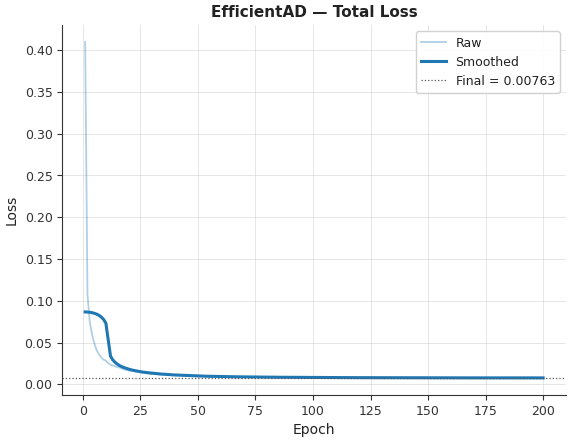

✅ Figure saved → 02a_ead_total_loss.png  (600 DPI)


'/kaggle/working/output/02a_ead_total_loss.png'

In [60]:
# ── Figure: EfficientAD — Total Loss ────────────────────────────────
apply_pub_style()
fig, ax = plt.subplots(figsize=(6.5, 4.8), facecolor='white')

epochs = range(1, len(EAD_HISTORY['loss']) + 1)
raw = np.array(EAD_HISTORY['loss'])
ax.plot(epochs, raw, color=CFG.C_EAD, linewidth=1.3, alpha=0.35, label='Raw')
if len(epochs) > 10:
    smooth = uniform_filter1d(raw, size=max(1, len(epochs)//10))
    ax.plot(epochs, smooth, color=CFG.C_EAD, linewidth=2.2, label='Smoothed')
ax.axhline(raw[-1], color='#555555', linewidth=0.9, linestyle=':',
           label=f'Final = {raw[-1]:.5f}')
ax.set_title('EfficientAD — Total Loss', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(loc='best')

plt.show()
save_fig(fig, '02a_ead_total_loss.png')


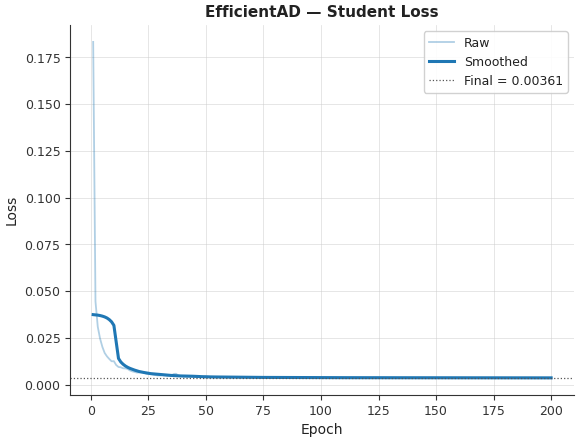

✅ Figure saved → 02b_ead_student_loss.png  (600 DPI)


'/kaggle/working/output/02b_ead_student_loss.png'

In [61]:
# ── Figure: EfficientAD — Student Loss ────────────────────────────────
apply_pub_style()
fig, ax = plt.subplots(figsize=(6.5, 4.8), facecolor='white')

epochs = range(1, len(EAD_HISTORY['student_loss']) + 1)
raw = np.array(EAD_HISTORY['student_loss'])
ax.plot(epochs, raw, color=CFG.C_EAD, linewidth=1.3, alpha=0.35, label='Raw')
if len(epochs) > 10:
    smooth = uniform_filter1d(raw, size=max(1, len(epochs)//10))
    ax.plot(epochs, smooth, color=CFG.C_EAD, linewidth=2.2, label='Smoothed')
ax.axhline(raw[-1], color='#555555', linewidth=0.9, linestyle=':',
           label=f'Final = {raw[-1]:.5f}')
ax.set_title('EfficientAD — Student Loss', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(loc='best')

plt.show()
save_fig(fig, '02b_ead_student_loss.png')


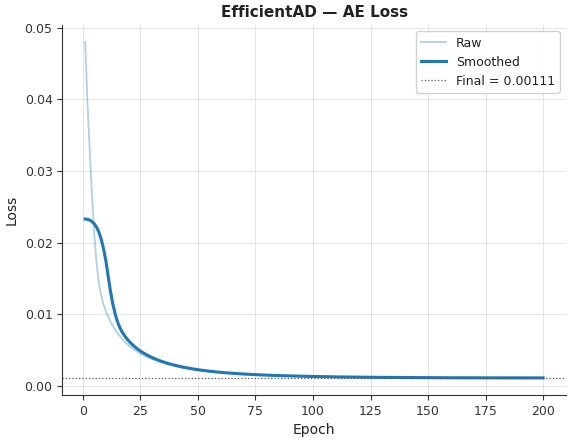

✅ Figure saved → 02c_ead_ae_loss.png  (600 DPI)


'/kaggle/working/output/02c_ead_ae_loss.png'

In [62]:
# ── Figure: EfficientAD — AE Loss ────────────────────────────────
apply_pub_style()
fig, ax = plt.subplots(figsize=(6.5, 4.8), facecolor='white')

epochs = range(1, len(EAD_HISTORY['ae_loss']) + 1)
raw = np.array(EAD_HISTORY['ae_loss'])
ax.plot(epochs, raw, color=CFG.C_EAD, linewidth=1.3, alpha=0.35, label='Raw')
if len(epochs) > 10:
    smooth = uniform_filter1d(raw, size=max(1, len(epochs)//10))
    ax.plot(epochs, smooth, color=CFG.C_EAD, linewidth=2.2, label='Smoothed')
ax.axhline(raw[-1], color='#555555', linewidth=0.9, linestyle=':',
           label=f'Final = {raw[-1]:.5f}')
ax.set_title('EfficientAD — AE Loss', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(loc='best')

plt.show()
save_fig(fig, '02c_ead_ae_loss.png')


In [63]:
# ── Cell: EfficientAD Anomaly Scoring ─────────────────────────────────────────
student_net.eval(); ae_net.eval()

def compute_ead_anomaly_scores(loader, device=DEVICE):
    all_maps, all_scores = [], []
    with torch.no_grad():
        for (x,) in loader:
            x = x.to(device)
            t_feat = teacher_net(imagenet_norm(x))
            s_feat = student_net(x)
            h = min(t_feat.shape[2], s_feat.shape[2])
            w = min(t_feat.shape[3], s_feat.shape[3])
            diff_map = ((t_feat[:,:,:h,:w] - s_feat[:,:,:h,:w])**2).mean(1, keepdim=True)
            diff_up  = F.interpolate(diff_map, size=(CFG.IMG_SIZE, CFG.IMG_SIZE),
                                     mode='bilinear', align_corners=False).squeeze(1)
            diff_up_np = diff_up.cpu().numpy()
            all_maps.append(diff_up_np)
            all_scores.append(diff_up_np.reshape(len(x), -1).mean(axis=1))
    return np.concatenate(all_maps), np.concatenate(all_scores)

print("🔄 Computing EfficientAD anomaly scores (val set) …")
_, ead_val_scores_raw = compute_ead_anomaly_scores(val_loader)

val_normal_mask = (y_val == 0)
q_lo  = np.percentile(ead_val_scores_raw[val_normal_mask], 1)
q_hi  = np.percentile(ead_val_scores_raw[~val_normal_mask]
                       if (~val_normal_mask).any()
                       else ead_val_scores_raw, 99)

def normalise_ead(scores):
    return np.clip((scores - q_lo) / (q_hi - q_lo + 1e-8), 0.0, 1.0)

ead_val_scores = normalise_ead(ead_val_scores_raw)
fpr_v, tpr_v, thr_v = roc_curve(y_val, ead_val_scores)
opt_thr_ead = thr_v[np.argmax(tpr_v - fpr_v)]

print("🔄 Computing EfficientAD anomaly scores (test set) …")
ead_test_maps, ead_test_scores_raw = compute_ead_anomaly_scores(test_loader)
ead_test_scores = normalise_ead(ead_test_scores_raw)

ead_auroc = roc_auc_score(y_test, ead_test_scores)
ead_ap    = average_precision_score(y_test, ead_test_scores)
ead_pred  = (ead_test_scores >= opt_thr_ead).astype(int)
ead_f1    = f1_score(y_test, ead_pred)
ead_mcc   = matthews_corrcoef(y_test, ead_pred)

print(f"\n📊 EfficientAD Test Results:")
print(f"   AUROC         : {ead_auroc:.4f}")
print(f"   Avg Precision : {ead_ap:.4f}")
print(f"   F1            : {ead_f1:.4f}")
print(f"   MCC           : {ead_mcc:.4f}")
print(f"   Threshold τ   : {opt_thr_ead:.4f}")
print(f"   Final Loss    : {EAD_HISTORY['loss'][-1]:.5f}")


🔄 Computing EfficientAD anomaly scores (val set) …
🔄 Computing EfficientAD anomaly scores (test set) …

📊 EfficientAD Test Results:
   AUROC         : 0.9799
   Avg Precision : 0.9998
   F1            : 0.9604
   MCC           : 0.2781
   Threshold τ   : 0.2726
   Final Loss    : 0.00763


### EfficientAD Test-Set Results
ROC curve, normalised anomaly-score distribution by ground-truth label, and the
precision–recall curve, all on the held-out test set.


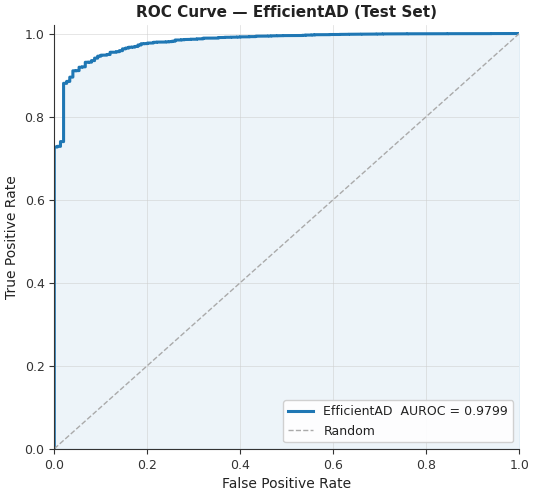

✅ Figure saved → 03a_ead_roc.png  (600 DPI)


'/kaggle/working/output/03a_ead_roc.png'

In [64]:
# ── Figure 3a: EfficientAD ROC Curve ──────────────────────────────────────────
apply_pub_style()
fig, ax = plt.subplots(figsize=(6, 5.5), facecolor='white')

fpr_t, tpr_t, _ = roc_curve(y_test, ead_test_scores)
ax.plot(fpr_t, tpr_t, color=CFG.C_EAD, linewidth=2.2,
        label=f'EfficientAD  AUROC = {ead_auroc:.4f}')
ax.plot([0,1],[0,1], color='#aaaaaa', linewidth=1.0, linestyle='--', label='Random')
ax.fill_between(fpr_t, tpr_t, alpha=0.08, color=CFG.C_EAD)
ax.set_title('ROC Curve — EfficientAD (Test Set)', fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

plt.show()
save_fig(fig, '03a_ead_roc.png')


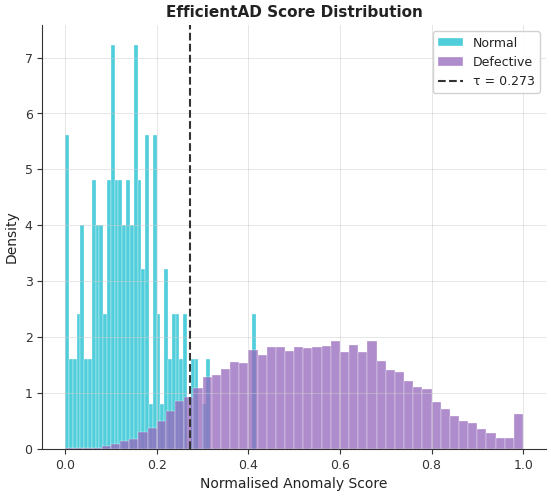

✅ Figure saved → 03b_ead_score_distribution.png  (600 DPI)


'/kaggle/working/output/03b_ead_score_distribution.png'

In [65]:
# ── Figure 3b: EfficientAD Score Distribution ─────────────────────────────────
apply_pub_style()
fig, ax = plt.subplots(figsize=(6.5, 5.5), facecolor='white')

ax.hist(ead_test_scores[y_test==0], bins=50, color=CFG.C_NORMAL,
        alpha=0.75, density=True, label='Normal', edgecolor='white', linewidth=0.3)
ax.hist(ead_test_scores[y_test==1], bins=50, color=CFG.C_DEFECT,
        alpha=0.75, density=True, label='Defective', edgecolor='white', linewidth=0.3)
ax.axvline(opt_thr_ead, color='#333333', linewidth=1.5, linestyle='--',
           label=f'τ = {opt_thr_ead:.3f}')
ax.set_title('EfficientAD Score Distribution', fontweight='bold')
ax.set_xlabel('Normalised Anomaly Score'); ax.set_ylabel('Density')
ax.legend(loc='upper right')

plt.show()
save_fig(fig, '03b_ead_score_distribution.png')


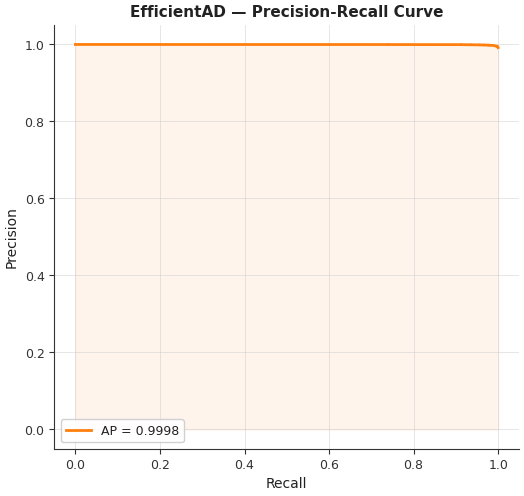

✅ Figure saved → 03c_ead_pr_curve.png  (600 DPI)


'/kaggle/working/output/03c_ead_pr_curve.png'

In [66]:
# ── Figure 3c: EfficientAD Precision-Recall Curve ─────────────────────────────
apply_pub_style()
fig, ax = plt.subplots(figsize=(6, 5.5), facecolor='white')

prec, rec, _ = precision_recall_curve(y_test, ead_test_scores)
ax.plot(rec, prec, color=CFG.C_ACCENT, linewidth=2.0, label=f'AP = {ead_ap:.4f}')
ax.fill_between(rec, prec, alpha=0.08, color=CFG.C_ACCENT)
ax.set_title('EfficientAD — Precision-Recall Curve', fontweight='bold')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.legend(loc='lower left')

plt.show()
save_fig(fig, '03c_ead_pr_curve.png')


###  EfficientAD Qualitative Anomaly Maps
Five representative test wafers with their EfficientAD anomaly-map overlay; the
border colour and check-mark indicate whether the prediction matched ground truth.


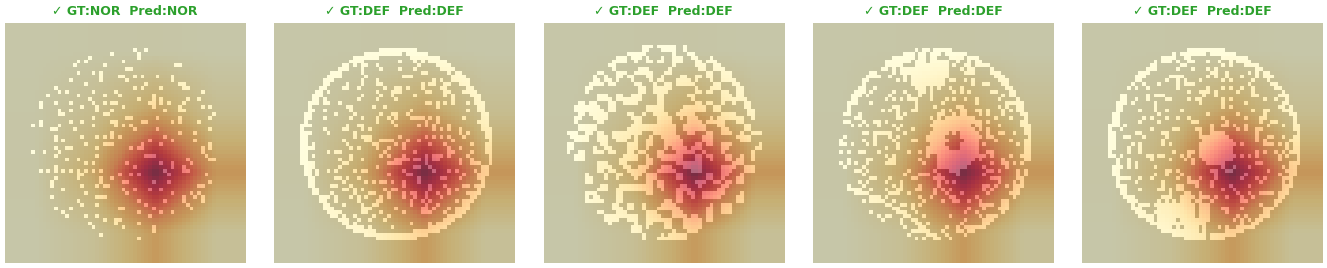

✅ Figure saved → 03d_ead_sample_anomaly_maps.png  (600 DPI)


'/kaggle/working/output/03d_ead_sample_anomaly_maps.png'

In [67]:
# ── Figure 3d: EfficientAD Sample Anomaly Maps ────────────────────────────────
apply_pub_style()
n_show = 5
test_arr = T_test.numpy()
sample_idxs = np.linspace(0, len(y_test)-1, n_show, dtype=int)

fig, axes = plt.subplots(1, n_show, figsize=(3.4*n_show, 4), facecolor='white')
fig.subplots_adjust(wspace=0.12)

for ax_i, si in zip(axes, sample_idxs):
    raw_img  = (test_arr[si, 2] + 1) / 2
    anom_map = ead_test_maps[si]
    anom_n   = (anom_map - anom_map.min()) / (anom_map.max() - anom_map.min() + 1e-8)
    label_s  = 'DEF' if y_test[si] else 'NOR'
    pred_s   = 'DEF' if ead_pred[si] else 'NOR'
    correct  = '✓' if label_s == pred_s else '✗'
    border_c = CFG.C_FUSION if label_s == pred_s else CFG.C_DDPM

    ax_i.imshow(raw_img, cmap='gray', interpolation='nearest', alpha=0.55)
    ax_i.imshow(anom_n, cmap=ANOM_CMAP, interpolation='nearest', alpha=0.60)
    ax_i.set_title(f'{correct} GT:{label_s}  Pred:{pred_s}',
                   fontsize=9, fontweight='bold',
                   color=CFG.C_FUSION if label_s == pred_s else CFG.C_DDPM)
    ax_i.axis('off')
    for spine in ax_i.spines.values():
        spine.set_visible(True); spine.set_edgecolor(border_c); spine.set_linewidth(2)

plt.show()
save_fig(fig, '03d_ead_sample_anomaly_maps.png')


---
#  DDPM: Generative Reconstruction Module

**Role:** detect *logical* anomalies — invalid spatial combinations of otherwise
normal-looking features — by learning the full distribution of defect-free wafer maps.
A wafer is partially noised out to timestep t\*, denoised back with DDIM, and the
reconstruction error against the original is used as an anomaly score.


In [68]:
# ── Cell: Diffusion Utilities — Cosine Schedule & EMA ────────────────────────

def cosine_beta_schedule(T: int, s: float = 0.008):
    steps    = T + 1
    t        = torch.linspace(0, T, steps, dtype=torch.float64)
    f_t      = torch.cos((t / T + s) / (1 + s) * math.pi / 2) ** 2
    alpha_bar = f_t / f_t[0]
    beta     = 1 - (alpha_bar[1:] / alpha_bar[:-1])
    return torch.clip(beta, 0.0001, 0.9999).float()

T_total        = CFG.DDPM_T
beta           = cosine_beta_schedule(T_total).to(DEVICE)
alpha          = 1.0 - beta
alpha_bar      = torch.cumprod(alpha, dim=0)
alpha_bar_prev = F.pad(alpha_bar[:-1], (1, 0), value=1.0)
sqrt_ab        = alpha_bar.sqrt()
sqrt_one_m_ab  = (1.0 - alpha_bar).sqrt()

def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    _sqrt_ab      = sqrt_ab[t].view(-1,1,1,1)
    _sqrt_one_m   = sqrt_one_m_ab[t].view(-1,1,1,1)
    return _sqrt_ab * x0 + _sqrt_one_m * noise

print(f"✅ Cosine noise schedule ready:")
print(f"   T={T_total} | β range [{beta[0]:.5f}, {beta[-1]:.5f}]")
print(f"   ᾱ at t=500 : {alpha_bar[500]:.4f}")


class EMAHelper:
    def __init__(self, model: nn.Module, decay: float = 0.9999):
        self.decay  = decay
        self.shadow = {k: v.clone().detach() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model: nn.Module):
        for k, v in model.state_dict().items():
            self.shadow[k] = self.decay * self.shadow[k] + (1 - self.decay) * v

    def apply_shadow(self, model: nn.Module):
        model.load_state_dict(self.shadow)

print("✅ EMAHelper class defined (decay=0.9999)")


✅ Cosine noise schedule ready:
   T=1000 | β range [0.00010, 0.99990]
   ᾱ at t=500 : 0.4921
✅ EMAHelper class defined (decay=0.9999)


In [69]:
# ── Cell: U-Net ε-Predictor Architecture ─────────────────────────────────────

class SinusoidalPositionEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__(); self.dim = dim
    def forward(self, t):
        device = t.device; half = self.dim // 2
        freqs = torch.exp(-math.log(10000) *
                          torch.arange(half, device=device) / (half - 1))
        args = t[:, None].float() * freqs[None]
        return torch.cat([args.sin(), args.cos()], dim=-1)


class TimeEmbedding(nn.Module):
    def __init__(self, sin_dim: int, time_dim: int):
        super().__init__()
        self.sin_emb = SinusoidalPositionEmbedding(sin_dim)
        self.mlp = nn.Sequential(
            nn.Linear(sin_dim, time_dim), nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )
    def forward(self, t): return self.mlp(self.sin_emb(t))


def _gn(channels: int) -> nn.GroupNorm:
    '''GroupNorm with a safe group count: the largest power-of-2 divisor of
    `channels` that is <= 32. Deterministic, depends only on `channels`, and
    always divides evenly.'''
    g = 32
    while g > 1 and channels % g != 0:
        g //= 2
    return nn.GroupNorm(g, channels)


class ResBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, time_dim: int):
        super().__init__()
        self.norm1     = _gn(in_ch)
        self.conv1     = nn.Conv2d(in_ch,  out_ch, 3, 1, 1)
        self.norm2     = _gn(out_ch)
        self.conv2     = nn.Conv2d(out_ch, out_ch, 3, 1, 1)
        self.act       = nn.SiLU()
        self.time_proj = nn.Linear(time_dim, out_ch)
        self.skip      = (nn.Conv2d(in_ch, out_ch, 1)
                          if in_ch != out_ch else nn.Identity())

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor):
        h = self.act(self.norm1(x))
        h = self.conv1(h)
        h = h + self.time_proj(self.act(t_emb))[:, :, None, None]
        h = self.act(self.norm2(h))
        h = self.conv2(h)
        return h + self.skip(x)


class SelfAttentionBlock(nn.Module):
    def __init__(self, channels: int, heads: int = 4):
        super().__init__()
        self.norm = _gn(channels)
        self.attn = nn.MultiheadAttention(channels, heads, batch_first=True)

    def forward(self, x: torch.Tensor):
        B, C, H, W = x.shape
        h = self.norm(x).view(B, C, -1).permute(0, 2, 1)
        h, _ = self.attn(h, h, h)
        return x + h.permute(0, 2, 1).view(B, C, H, W)


class UNet(nn.Module):
    '''
    U-Net ε-predictor. Channel layout (base_ch=48, mults=(1,2,4)):
        Encoder    : 48 → 96 → 192
        Bottleneck : 192 → 192 (3 ResBlocks + attention)
        Decoder    : 192+192→192 → 96+96→96 → 48+48→48
        Output     : Conv2d(48, 3)
    '''
    def __init__(
        self,
        in_ch    : int   = 3,
        out_ch   : int   = 3,
        base_ch  : int   = 48,
        ch_mults : tuple = (1, 2, 4),
        n_blocks : int   = 2,
        n_mid    : int   = 3,
        time_dim : int   = 320,
        attn_res : tuple = (16,),
    ):
        super().__init__()
        C = [base_ch * m for m in ch_mults]   # [48, 96, 192]
        n_levels = len(C)

        self.time_emb  = TimeEmbedding(sin_dim=128, time_dim=time_dim)
        self.init_conv = nn.Conv2d(in_ch, C[0], 3, 1, 1)

        # ── Encoder ──────────────────────────────────────────────────────────
        self.enc_blocks = nn.ModuleList()
        self.down_ops   = nn.ModuleList()
        cur_res = CFG.IMG_SIZE   # 64

        for lv in range(n_levels):
            level = nn.ModuleList()
            for bi in range(n_blocks):
                blk_in = C[lv] if bi > 0 else (C[0] if lv == 0 else C[lv])
                level.append(ResBlock(blk_in, C[lv], time_dim))
                if cur_res in attn_res:
                    level.append(SelfAttentionBlock(C[lv]))
            self.enc_blocks.append(level)

            if lv < n_levels - 1:
                self.down_ops.append(
                    nn.Conv2d(C[lv], C[lv + 1], 3, stride=2, padding=1))
                cur_res //= 2
            else:
                self.down_ops.append(nn.Identity())

        # ── Bottleneck ───────────────────────────────────────────────────────
        bot = C[-1]
        mid_layers = [ResBlock(bot, bot, time_dim), SelfAttentionBlock(bot)]
        for _ in range(n_mid - 1):
            mid_layers.append(ResBlock(bot, bot, time_dim))
        self.mid = nn.ModuleList(mid_layers)

        # ── Decoder ──────────────────────────────────────────────────────────
        self.dec_blocks = nn.ModuleList()
        self.up_ops     = nn.ModuleList()
        cur_res = CFG.IMG_SIZE // (2 ** (n_levels - 1))

        for lv in range(n_levels):
            enc_lv  = n_levels - 1 - lv
            skip_ch = C[enc_lv]
            up_ch   = C[enc_lv]
            out_ch_ = C[enc_lv]

            level = nn.ModuleList()
            for bi in range(n_blocks):
                blk_in = (up_ch + skip_ch) if bi == 0 else out_ch_
                level.append(ResBlock(blk_in, out_ch_, time_dim))
                if cur_res in attn_res:
                    level.append(SelfAttentionBlock(out_ch_))
            self.dec_blocks.append(level)

            if lv < n_levels - 1:
                next_enc_lv = enc_lv - 1
                self.up_ops.append(
                    nn.ConvTranspose2d(out_ch_, C[next_enc_lv], 2, stride=2))
                cur_res *= 2
            else:
                self.up_ops.append(nn.Identity())

        self.final_norm = _gn(C[0])
        self.final_conv = nn.Conv2d(C[0], out_ch, 3, 1, 1)

    def _enc_level(self, x, t_emb, blocks):
        for blk in blocks:
            x = blk(x) if isinstance(blk, SelfAttentionBlock) else blk(x, t_emb)
        return x

    def _dec_level(self, x, t_emb, skip, blocks):
        x = torch.cat([x, skip], dim=1)
        for blk in blocks:
            x = blk(x) if isinstance(blk, SelfAttentionBlock) else blk(x, t_emb)
        return x

    def forward(self, x: torch.Tensor, t: torch.Tensor):
        t_emb = self.time_emb(t)
        x     = self.init_conv(x)

        skips = []
        for level_blocks, down in zip(self.enc_blocks, self.down_ops):
            x = self._enc_level(x, t_emb, level_blocks)
            skips.append(x)
            x = down(x)

        for blk in self.mid:
            x = blk(x) if isinstance(blk, SelfAttentionBlock) else blk(x, t_emb)

        for lv, (level_blocks, up) in enumerate(zip(self.dec_blocks, self.up_ops)):
            x = self._dec_level(x, t_emb, skips[-(lv + 1)], level_blocks)
            x = up(x)

        return self.final_conv(F.silu(self.final_norm(x)))


# ── Instantiate & verify ──────────────────────────────────────────────────────
ddpm_unet = UNet(
    base_ch=CFG.DDPM_BASE_CH, ch_mults=CFG.DDPM_CH_MULTS,
    n_blocks=CFG.DDPM_N_BLOCKS, time_dim=CFG.DDPM_TIME_DIM,
    attn_res=CFG.DDPM_ATTN_RES,
).to(DEVICE)
n_params  = sum(p.numel() for p in ddpm_unet.parameters())
print(f"✅ DDPM U-Net instantiated")
print(f"   Parameters : {n_params/1e6:.2f} M")
print(f"   Channels   : {[CFG.DDPM_BASE_CH * m for m in CFG.DDPM_CH_MULTS]}")
print(f"   Time dim   : {CFG.DDPM_TIME_DIM}")
print(f"   Attention  : at resolutions {CFG.DDPM_ATTN_RES}")

with torch.no_grad():
    _x   = torch.zeros(2, 3, 64, 64, device=DEVICE)
    _t   = torch.randint(0, T_total, (2,), device=DEVICE)
    _out = ddpm_unet(_x, _t)
    print(f"\n📐 I/O: Input {tuple(_x.shape)} → Output {tuple(_out.shape)}")
    assert _out.shape == _x.shape, f"Shape mismatch: {_out.shape} != {_x.shape}"
    print("✅ Shape check passed.")


✅ DDPM U-Net instantiated
   Parameters : 7.83 M
   Channels   : [48, 96, 192]
   Time dim   : 320
   Attention  : at resolutions (16,)

📐 I/O: Input (2, 3, 64, 64) → Output (2, 3, 64, 64)
✅ Shape check passed.


In [70]:
# ── Cell: DDPM Training (Cosine Schedule, EMA) ───────────────────────────────
ddpm_optimizer = torch.optim.AdamW(
    ddpm_unet.parameters(), lr=CFG.DDPM_LR, weight_decay=1e-5)
ddpm_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    ddpm_optimizer, T_max=CFG.DDPM_EPOCHS, eta_min=1e-6)
ddpm_ema = EMAHelper(ddpm_unet, decay=CFG.DDPM_EMA_DECAY)

ddpm_loader = DataLoader(TensorDataset(T_train), batch_size=CFG.DDPM_BS,
                         shuffle=True, num_workers=_n_workers,
                         pin_memory=True, drop_last=True)

DDPM_HISTORY = {'loss': []}

print(f"🔄 Training DDPM for {CFG.DDPM_EPOCHS} epochs …")
print(f"   U-Net params   : {n_params/1e6:.2f} M")
print(f"   Batch size     : {CFG.DDPM_BS}")
print("-" * 60)

for epoch in range(1, CFG.DDPM_EPOCHS + 1):
    ddpm_unet.train()
    ep_loss = 0.0
    for (x0,) in ddpm_loader:
        x0  = x0.to(DEVICE)
        t   = torch.randint(0, T_total, (x0.shape[0],), device=DEVICE)
        eps = torch.randn_like(x0)
        x_t = q_sample(x0, t, noise=eps)
        eps_pred = ddpm_unet(x_t, t)
        loss = F.mse_loss(eps_pred, eps)
        ddpm_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ddpm_unet.parameters(), 1.0)
        ddpm_optimizer.step()
        ddpm_ema.update(ddpm_unet)
        ep_loss += loss.item()

    ep_loss /= len(ddpm_loader)
    DDPM_HISTORY['loss'].append(ep_loss)
    ddpm_scheduler.step()
    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:>3}/{CFG.DDPM_EPOCHS} | Loss = {ep_loss:.5f}")

# Swap in EMA weights for inference (the raw trained weights are discarded —
# EMA is used throughout the rest of the notebook for scoring and sampling).
ddpm_ema.apply_shadow(ddpm_unet)
ddpm_unet.eval()

print(f"\n✅ DDPM training complete.")
print(f"   Final loss   : {DDPM_HISTORY['loss'][-1]:.5f}")
print(f"   EMA weights applied for inference.")


🔄 Training DDPM for 30 epochs …
   U-Net params   : 7.83 M
   Batch size     : 32
------------------------------------------------------------
  Epoch   1/30 | Loss = 0.62178
  Epoch   5/30 | Loss = 0.14725
  Epoch  10/30 | Loss = 0.08875
  Epoch  15/30 | Loss = 0.06922
  Epoch  20/30 | Loss = 0.06189
  Epoch  25/30 | Loss = 0.05405
  Epoch  30/30 | Loss = 0.05161

✅ DDPM training complete.
   Final loss   : 0.05161
   EMA weights applied for inference.


###  DDPM Training Loss


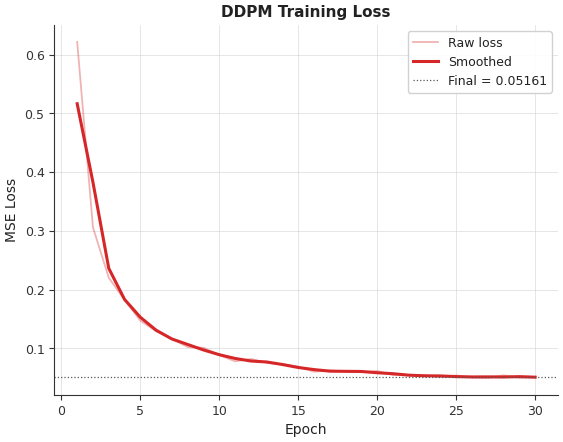

✅ Figure saved → 04_ddpm_training_loss.png  (600 DPI)


'/kaggle/working/output/04_ddpm_training_loss.png'

In [71]:
# ── Figure 4: DDPM Training Loss ──────────────────────────────────────────────
apply_pub_style()
fig, ax = plt.subplots(figsize=(6.5, 4.8), facecolor='white')

eps_r = range(1, len(DDPM_HISTORY['loss']) + 1)
raw_d = np.array(DDPM_HISTORY['loss'])
ax.plot(eps_r, raw_d, color=CFG.C_DDPM, linewidth=1.3, alpha=0.35, label='Raw loss')
if len(eps_r) > 3:
    ax.plot(eps_r, uniform_filter1d(raw_d, size=3), color=CFG.C_DDPM,
            linewidth=2.2, label='Smoothed')
ax.axhline(raw_d[-1], color='#555555', linewidth=0.9, linestyle=':',
           label=f'Final = {raw_d[-1]:.5f}')
ax.set_title('DDPM Training Loss', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend(loc='best')

plt.show()
save_fig(fig, '04_ddpm_training_loss.png')


In [72]:
# ── Cell: DDIM Sampler & Sampling-Speed Benchmark ────────────────────────────

@torch.no_grad()
def ddim_sample(model, shape, steps=50, device=DEVICE, eta=0.0):
    t_seq = torch.linspace(T_total - 1, 0, steps + 1).long().to(device)
    x     = torch.randn(shape, device=device)
    for i in range(len(t_seq) - 1):
        t_cur = t_seq[i]; t_nxt = t_seq[i + 1]
        eps   = model(x, t_cur.expand(shape[0]))
        ab_t  = alpha_bar[t_cur]
        # t_nxt is always >= 0 by construction of t_seq (it ends at 0, not
        # below), so the terminal step uses alpha_bar[0] (very close to but
        # not exactly 1.0). Kept consistent with `ddim_denoise_from` below.
        ab_n  = alpha_bar[t_nxt] if t_nxt > 0 else torch.tensor(1.0, device=device)
        x0_p  = ((x - (1 - ab_t).sqrt() * eps) / ab_t.sqrt()).clamp(-1.0, 1.0)
        sigma = eta * ((1-ab_n)/(1-ab_t) * (1-ab_t/ab_n)).sqrt()
        noise = torch.randn_like(x) if eta > 0 else 0
        x     = ab_n.sqrt() * x0_p + (1-ab_n-sigma**2).sqrt() * eps + sigma * noise
    return x.clamp(-1.0, 1.0)

@torch.no_grad()
def ddim_denoise_from(model, x_t, t_start, steps=50, device=DEVICE):
    t_seq = torch.linspace(t_start, 0, steps + 1).long().to(device)
    x = x_t.clone()
    for i in range(len(t_seq) - 1):
        t_cur = t_seq[i]; t_nxt = t_seq[i + 1]
        eps   = model(x, t_cur.expand(x.shape[0]))
        ab_t  = alpha_bar[t_cur]
        ab_n  = alpha_bar[t_nxt] if t_nxt > 0 else torch.tensor(1.0, device=device)
        x0_p  = ((x - (1-ab_t).sqrt()*eps) / ab_t.sqrt()).clamp(-1.0, 1.0)
        x     = ab_n.sqrt() * x0_p + (1-ab_n).sqrt() * eps
    return x.clamp(-1.0, 1.0)

print(f"⏱  Benchmarking DDIM sampling ({CFG.DDPM_DDIM_STEPS} steps) …")
_shape = (CFG.DDPM_BS, 3, CFG.IMG_SIZE, CFG.IMG_SIZE)
ddim_sample(ddpm_unet, _shape, steps=CFG.DDPM_DDIM_STEPS)   # warm-up

N_BENCH = 5
t0 = time.perf_counter()
for _ in range(N_BENCH):
    ddim_sample(ddpm_unet, _shape, steps=CFG.DDPM_DDIM_STEPS)
elapsed = time.perf_counter() - t0
sampling_rate = N_BENCH * CFG.DDPM_DDIM_STEPS / elapsed
print(f"✅ Sampling rate : {sampling_rate:.2f} it/s")


⏱  Benchmarking DDIM sampling (50 steps) …
✅ Sampling rate : 11.14 it/s


In [73]:
# ── Cell: DDPM Reconstruction-Based Anomaly Scoring ──────────────────────────
RECON_T = CFG.DDPM_RECON_T

def compute_ddpm_anomaly_scores(loader, t_star=RECON_T, ddim_steps=CFG.DDPM_DDIM_STEPS, device=DEVICE):
    all_maps, all_scores = [], []
    with torch.no_grad():
        for (x,) in loader:
            x = x.to(device)
            B = x.shape[0]
            t_tensor = torch.full((B,), t_star, device=device, dtype=torch.long)
            x_noisy  = q_sample(x, t_tensor)
            x_recon  = ddim_denoise_from(ddpm_unet, x_noisy, t_start=t_star, steps=ddim_steps)
            amap     = ((x - x_recon)**2).mean(dim=1)    # (B, 64, 64)
            amap_np  = amap.cpu().numpy()
            all_maps.append(amap_np)
            all_scores.append(amap_np.reshape(B, -1).mean(axis=1))
    return np.concatenate(all_maps), np.concatenate(all_scores)

print(f"🔄 Computing DDPM reconstruction scores (val set, t*={RECON_T}) …")
ddpm_val_maps, ddpm_val_scores_raw = compute_ddpm_anomaly_scores(val_loader)

val_norm_mask = (y_val == 0)
q_lo_d = np.percentile(ddpm_val_scores_raw[val_norm_mask], 1)
q_hi_d = np.percentile(ddpm_val_scores_raw[~val_norm_mask]
                        if (~val_norm_mask).any() else ddpm_val_scores_raw, 99)

def normalise_ddpm(sc):
    return np.clip((sc - q_lo_d) / (q_hi_d - q_lo_d + 1e-8), 0.0, 1.0)

ddpm_val_scores = normalise_ddpm(ddpm_val_scores_raw)
fpr_dv, tpr_dv, thr_dv = roc_curve(y_val, ddpm_val_scores)
opt_thr_ddpm = thr_dv[np.argmax(tpr_dv - fpr_dv)]

print("🔄 Computing DDPM reconstruction scores (test set) …")
ddpm_test_maps, ddpm_test_scores_raw = compute_ddpm_anomaly_scores(test_loader)
ddpm_test_scores = normalise_ddpm(ddpm_test_scores_raw)

ddpm_auroc = roc_auc_score(y_test, ddpm_test_scores)
ddpm_ap    = average_precision_score(y_test, ddpm_test_scores)
ddpm_pred  = (ddpm_test_scores >= opt_thr_ddpm).astype(int)
ddpm_f1    = f1_score(y_test, ddpm_pred)
ddpm_mcc   = matthews_corrcoef(y_test, ddpm_pred)

print(f"\n📊 DDPM Test Results:")
print(f"   AUROC         : {ddpm_auroc:.4f}")
print(f"   Avg Precision : {ddpm_ap:.4f}")
print(f"   F1            : {ddpm_f1:.4f}")
print(f"   MCC           : {ddpm_mcc:.4f}")
print(f"   Final Loss    : {DDPM_HISTORY['loss'][-1]:.5f}")
print(f"   U-Net Params  : {n_params/1e6:.2f} M")


🔄 Computing DDPM reconstruction scores (val set, t*=500) …
🔄 Computing DDPM reconstruction scores (test set) …

📊 DDPM Test Results:
   AUROC         : 0.9931
   Avg Precision : 0.9999
   F1            : 0.9764
   MCC           : 0.3620
   Final Loss    : 0.05161
   U-Net Params  : 7.83 M


###  DDPM Test-Set Results
ROC curve, score distribution, a set of original test wafers with their DDIM
reconstruction-error maps, and finally a batch of purely synthetic normal wafers
sampled from the trained diffusion model.


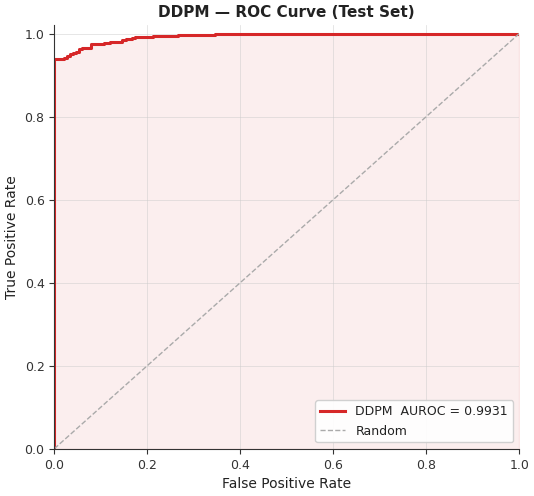

✅ Figure saved → 05a_ddpm_roc.png  (600 DPI)


'/kaggle/working/output/05a_ddpm_roc.png'

In [74]:
# ── Figure 5a: DDPM ROC Curve ──────────────────────────────────────────────────
apply_pub_style()
fig, ax = plt.subplots(figsize=(6, 5.5), facecolor='white')

fpr_d, tpr_d, _ = roc_curve(y_test, ddpm_test_scores)
ax.plot(fpr_d, tpr_d, color=CFG.C_DDPM, linewidth=2.2, label=f'DDPM  AUROC = {ddpm_auroc:.4f}')
ax.fill_between(fpr_d, tpr_d, alpha=0.08, color=CFG.C_DDPM)
ax.plot([0,1],[0,1], color='#aaaaaa', linewidth=1.0, linestyle='--', label='Random')
ax.set_title('DDPM — ROC Curve (Test Set)', fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right'); ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

plt.show()
save_fig(fig, '05a_ddpm_roc.png')


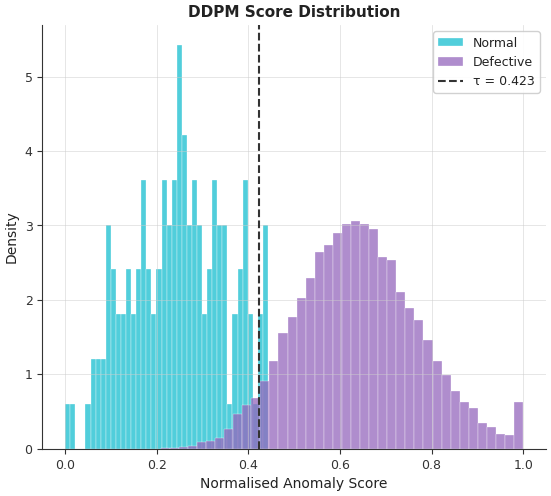

✅ Figure saved → 05b_ddpm_score_distribution.png  (600 DPI)


'/kaggle/working/output/05b_ddpm_score_distribution.png'

In [75]:
# ── Figure 5b: DDPM Score Distribution ────────────────────────────────────────
apply_pub_style()
fig, ax = plt.subplots(figsize=(6.5, 5.5), facecolor='white')

ax.hist(ddpm_test_scores[y_test==0], bins=40, color=CFG.C_NORMAL,
        alpha=0.75, density=True, label='Normal', edgecolor='white', linewidth=0.3)
ax.hist(ddpm_test_scores[y_test==1], bins=40, color=CFG.C_DEFECT,
        alpha=0.75, density=True, label='Defective', edgecolor='white', linewidth=0.3)
ax.axvline(opt_thr_ddpm, color='#333333', linewidth=1.5, linestyle='--',
           label=f'τ = {opt_thr_ddpm:.3f}')
ax.set_title('DDPM Score Distribution', fontweight='bold')
ax.set_xlabel('Normalised Anomaly Score'); ax.set_ylabel('Density')
ax.legend(loc='upper right')

plt.show()
save_fig(fig, '05b_ddpm_score_distribution.png')


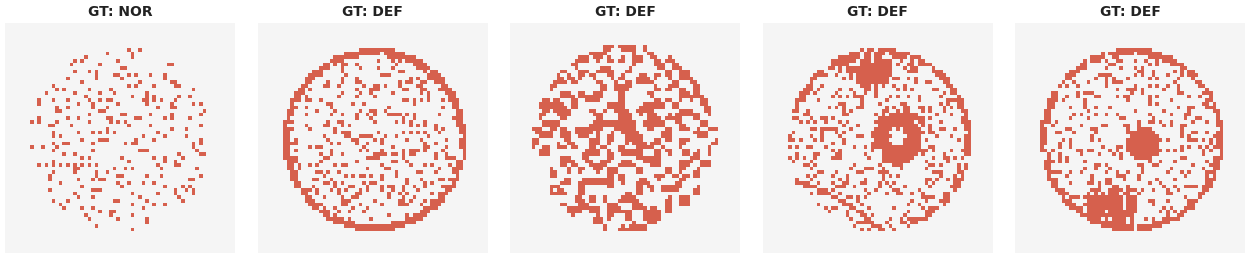

✅ Figure saved → 05c_ddpm_original_wafers.png  (600 DPI)


'/kaggle/working/output/05c_ddpm_original_wafers.png'

In [76]:
# ── Figure 5c: DDPM — Original Test Wafers ────────────────────────────────────
apply_pub_style()
sids = np.linspace(0, len(y_test)-1, 5, dtype=int)
fig, axes = plt.subplots(1, 5, figsize=(3.2*5, 3.6), facecolor='white')
fig.subplots_adjust(wspace=0.10)

for ax_o, si in zip(axes, sids):
    orig_arr  = T_test[si].numpy()
    disp_orig = (orig_arr[2] + 1) / 2
    label_s   = 'DEF' if y_test[si] else 'NOR'
    ax_o.imshow(disp_orig, cmap=WBM_CMAP, interpolation='nearest')
    ax_o.set_title(f'GT: {label_s}', fontsize=10, fontweight='bold')
    ax_o.axis('off')

plt.show()
save_fig(fig, '05c_ddpm_original_wafers.png')


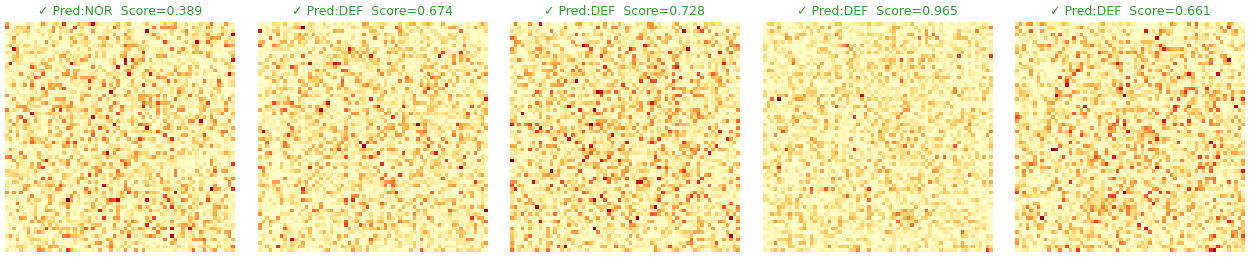

✅ Figure saved → 05d_ddpm_reconstruction_error_maps.png  (600 DPI)


'/kaggle/working/output/05d_ddpm_reconstruction_error_maps.png'

In [78]:
# ── Figure 5d: DDPM — Reconstruction-Error Maps (same wafers as 5c) ──────────
apply_pub_style()
fig, axes = plt.subplots(1, 5, figsize=(3.2*5, 3.6), facecolor='white')
fig.subplots_adjust(wspace=0.10)

for ax_m, si in zip(axes, sids):
    amap    = ddpm_test_maps[si]
    amap_n  = (amap - amap.min()) / (amap.max() - amap.min() + 1e-8)
    label_s = 'DEF' if y_test[si] else 'NOR'
    pred_s  = 'DEF' if ddpm_pred[si] else 'NOR'
    correct = '✓' if pred_s == label_s else '✗'
    ax_m.imshow(amap_n, cmap=ANOM_CMAP, interpolation='nearest')
    ax_m.set_title(f'{correct} Pred:{pred_s}  Score={ddpm_test_scores[si]:.3f}',
                   fontsize=9, color=CFG.C_FUSION if pred_s==label_s else CFG.C_DDPM)
    ax_m.axis('off')

plt.show()
save_fig(fig, '05d_ddpm_reconstruction_error_maps.png')


🔄 Generating synthetic normal WBMs via DDIM …


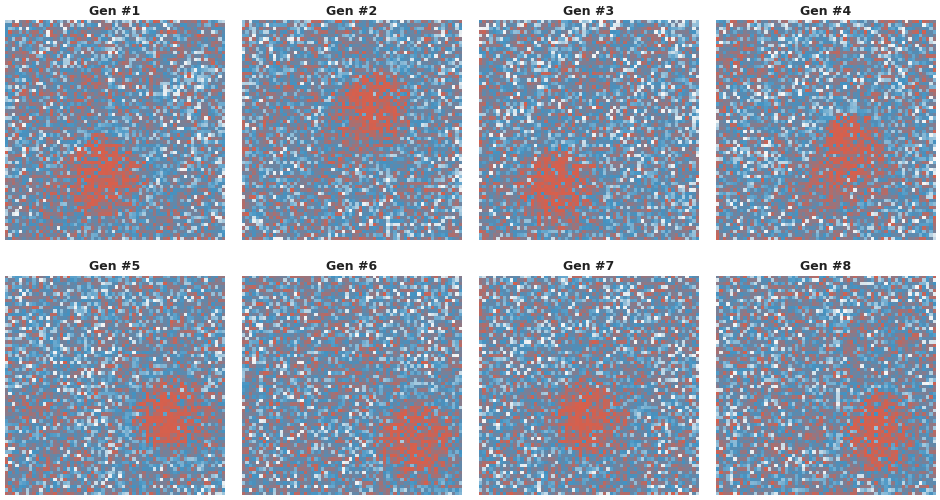

✅ Figure saved → 05e_ddpm_generated_samples.png  (600 DPI)


'/kaggle/working/output/05e_ddpm_generated_samples.png'

In [79]:
# ── Figure 5e: DDPM Generated (DDIM) Synthetic Normal Wafers ─────────────────
print("🔄 Generating synthetic normal WBMs via DDIM …")
gen_imgs = ddim_sample(ddpm_unet, (8, 3, CFG.IMG_SIZE, CFG.IMG_SIZE),
                        steps=CFG.DDPM_DDIM_STEPS).cpu().numpy()

apply_pub_style()
fig, axes = plt.subplots(2, 4, figsize=(12, 6.2), facecolor='white')
fig.subplots_adjust(hspace=0.15, wspace=0.08)
for i, ax in enumerate(axes.flatten()):
    disp = (gen_imgs[i, 2] + 1) / 2
    ax.imshow(disp, cmap=WBM_CMAP, interpolation='nearest', vmin=0, vmax=1)
    ax.set_title(f'Gen #{i+1}', fontsize=9, fontweight='bold', pad=4)
    ax.axis('off')

plt.show()
save_fig(fig, '05e_ddpm_generated_samples.png')


---
# Fusion: Structural + Generative Scores

```
score_fused(x) = α · score_EAD(x) + (1−α) · score_DDPM(x)
```

Both modules process each image in a single pass. The default is α = 0.5 (equal
weight); Part IV below sweeps α to check whether 0.5 is actually a good choice.


In [80]:
# ── Cell: Score Fusion & Optimal Threshold ───────────────────────────────────
ALPHA = CFG.FUSION_ALPHA    # 0.5

fused_val = ALPHA * ead_val_scores + (1 - ALPHA) * ddpm_val_scores
fpr_fv, tpr_fv, thr_fv = roc_curve(y_val, fused_val)
opt_thr_fused = thr_fv[np.argmax(tpr_fv - fpr_fv)]

fused_test  = ALPHA * ead_test_scores + (1 - ALPHA) * ddpm_test_scores
fused_pred  = (fused_test >= opt_thr_fused).astype(int)

fused_auroc = roc_auc_score(y_test, fused_test)
fused_ap    = average_precision_score(y_test, fused_test)
fused_f1    = f1_score(y_test, fused_pred)
fused_mcc   = matthews_corrcoef(y_test, fused_pred)
fused_bal   = balanced_accuracy_score(y_test, fused_pred)

print("📊 Fused Module Test Results:")
print(f"   AUROC         : {fused_auroc:.4f}")
print(f"   Avg Precision : {fused_ap:.4f}")
print(f"   F1            : {fused_f1:.4f}")
print(f"   MCC           : {fused_mcc:.4f}")
print(f"   Balanced Acc  : {fused_bal:.4f}")

print(f"\n📊 Comparison (Test Set AUROC):")
print(f"   EfficientAD   : {ead_auroc:.4f}")
print(f"   DDPM          : {ddpm_auroc:.4f}")
print(f"   Fused (α=0.5) : {fused_auroc:.4f}")

# Spatial map fusion
def norm_map(m):
    mn = m.min(axis=(1,2), keepdims=True)
    mx = m.max(axis=(1,2), keepdims=True)
    return (m - mn) / (mx - mn + 1e-8)

ead_maps_n  = norm_map(ead_test_maps)
ddpm_maps_n = norm_map(ddpm_test_maps)
fused_maps  = ALPHA * ead_maps_n + (1 - ALPHA) * ddpm_maps_n
print("\n✅ Spatial anomaly map fusion complete. Shape:", fused_maps.shape)


📊 Fused Module Test Results:
   AUROC         : 0.9985
   Avg Precision : 1.0000
   F1            : 0.9830
   MCC           : 0.4321
   Balanced Acc  : 0.9800

📊 Comparison (Test Set AUROC):
   EfficientAD   : 0.9799
   DDPM          : 0.9931
   Fused (α=0.5) : 0.9985

✅ Spatial anomaly map fusion complete. Shape: (18658, 64, 64)


###  Three-Way Curve Comparison
ROC, precision–recall, and calibration/reliability, each comparing EfficientAD, DDPM,
and the fused score on the same test set.


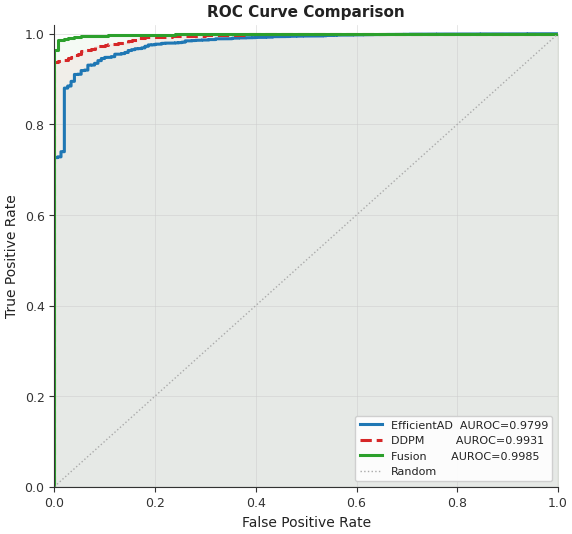

✅ Figure saved → 06a_three_way_roc.png  (600 DPI)


'/kaggle/working/output/06a_three_way_roc.png'

In [81]:
# ── Figure 6a: Three-Way ROC Comparison ───────────────────────────────────────
apply_pub_style()
fig, ax = plt.subplots(figsize=(6.5, 6), facecolor='white')

for scores, label, color, ls in [
    (ead_test_scores,  f'EfficientAD  AUROC={ead_auroc:.4f}',  CFG.C_EAD,    '-'),
    (ddpm_test_scores, f'DDPM         AUROC={ddpm_auroc:.4f}',  CFG.C_DDPM,   '--'),
    (fused_test,       f'Fusion       AUROC={fused_auroc:.4f}', CFG.C_FUSION, '-'),
]:
    fpr_, tpr_, _ = roc_curve(y_test, scores)
    ax.plot(fpr_, tpr_, color=color, linewidth=2.2, linestyle=ls, label=label)
    ax.fill_between(fpr_, tpr_, alpha=0.05, color=color)
ax.plot([0,1],[0,1], color='#aaaaaa', linewidth=1.0, linestyle=':', label='Random')
ax.set_title('ROC Curve Comparison', fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=8); ax.set_xlim(0,1); ax.set_ylim(0,1.02)

plt.show()
save_fig(fig, '06a_three_way_roc.png')


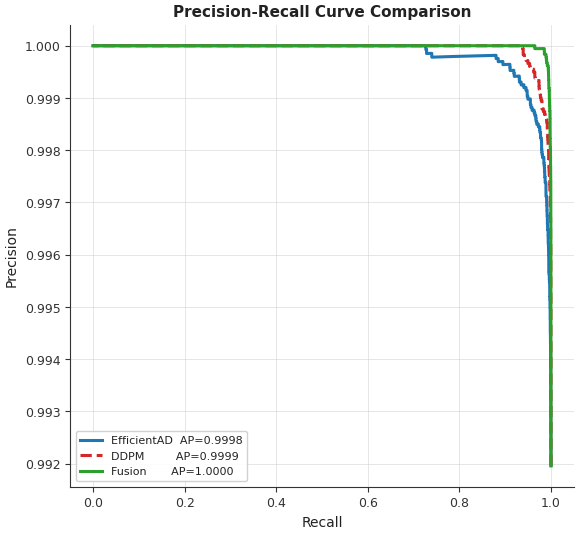

✅ Figure saved → 06b_three_way_pr.png  (600 DPI)


'/kaggle/working/output/06b_three_way_pr.png'

In [83]:
# ── Figure 6b: Three-Way Precision-Recall Comparison ─────────────────────────
apply_pub_style()
fig, ax = plt.subplots(figsize=(6.5, 6), facecolor='white')

for scores, label, color, ls in [
    (ead_test_scores,  f'EfficientAD  AP={ead_ap:.4f}',  CFG.C_EAD,    '-'),
    (ddpm_test_scores, f'DDPM         AP={ddpm_ap:.4f}',  CFG.C_DDPM,   '--'),
    (fused_test,       f'Fusion       AP={fused_ap:.4f}', CFG.C_FUSION, '-'),
]:
    p_, r_, _ = precision_recall_curve(y_test, scores)
    ax.plot(r_, p_, color=color, linewidth=2.2, linestyle=ls, label=label)
ax.set_title('Precision-Recall Curve Comparison', fontweight='bold')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.legend(loc='lower left', fontsize=8)

plt.show()
save_fig(fig, '06b_three_way_pr.png')


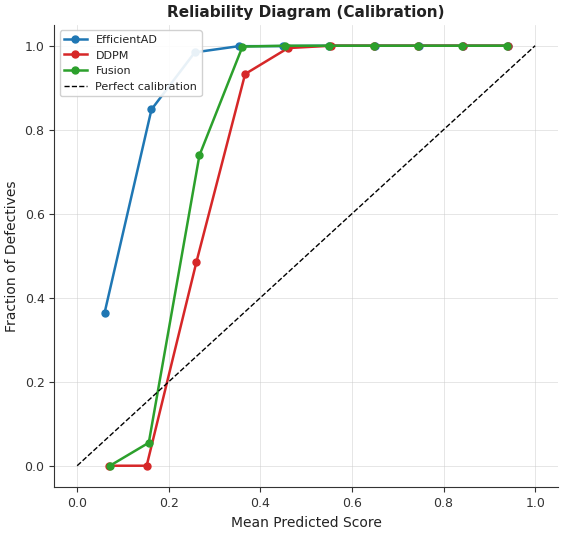

✅ Figure saved → 06c_reliability_diagram.png  (600 DPI)


'/kaggle/working/output/06c_reliability_diagram.png'

In [84]:
# ── Figure 6c: Reliability / Calibration Diagram ─────────────────────────────
apply_pub_style()
fig, ax = plt.subplots(figsize=(6.5, 6), facecolor='white')

n_bins = 10
for scores, label, color in [
    (ead_test_scores,  'EfficientAD', CFG.C_EAD),
    (ddpm_test_scores, 'DDPM',        CFG.C_DDPM),
    (fused_test,       'Fusion',      CFG.C_FUSION),
]:
    edges = np.linspace(0, 1, n_bins + 1)
    bm, bf = [], []
    for lo_b, hi_b in zip(edges[:-1], edges[1:]):
        mask = (scores >= lo_b) & (scores < hi_b)
        if mask.sum() > 0:
            bm.append(scores[mask].mean())
            bf.append(y_test[mask].mean())
    if bm:
        ax.plot(bm, bf, marker='o', markersize=5, color=color, linewidth=1.8, label=label)
ax.plot([0,1],[0,1], 'k--', linewidth=1.0, label='Perfect calibration')
ax.set_title('Reliability Diagram (Calibration)', fontweight='bold')
ax.set_xlabel('Mean Predicted Score'); ax.set_ylabel('Fraction of Defectives')
ax.legend(loc='upper left', fontsize=8)

plt.show()
save_fig(fig, '06c_reliability_diagram.png')


---
# Statistical Validation

Point estimates alone don't tell us whether the differences between EfficientAD,
DDPM, and their fusion are real or could plausibly be sampling noise. This section
reports (1) bootstrap 95% confidence intervals per model, (2) a **paired** bootstrap
test for AUROC differences that accounts for the fact all three models are scored
on the *same* test wafers, (3) the analytical **DeLong test** for correlated ROC
curves, and (4) **McNemar's test** on the thresholded predictions.


In [ ]:
# ── Cell: Bootstrap 95% CI (bug-fixed) + Comprehensive Metrics ───────────────
RNG = np.random.default_rng(CFG.SEED)

def bootstrap_ci(y_true, scores, preds, metric_fn, n_boot=CFG.N_BOOTSTRAP,
                  ci=CFG.CI_LEVEL, max_attempts_factor=20):
   
    n = len(y_true)
    vals = []
    attempts = 0
    max_attempts = n_boot * max_attempts_factor
    while len(vals) < n_boot and attempts < max_attempts:
        attempts += 1
        idx = RNG.integers(0, n, size=n)
        if len(np.unique(y_true[idx])) < 2:
            continue   # degenerate resample: skip rather than silently poison the CI
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            v = metric_fn(y_true[idx], scores[idx])
        if np.isfinite(v):
            vals.append(v)
    if len(vals) < n_boot:
        print(f"   ⚠️  Only {len(vals)}/{n_boot} valid bootstrap resamples "
              f"after {attempts} attempts (class imbalance is severe).")
    vals = np.array(vals)
    lo = np.percentile(vals, 100*(1-ci)/2)
    hi = np.percentile(vals, 100*(1-(1-ci)/2))
    return float(np.mean(vals)), lo, hi

def all_metrics(y_true, scores, preds, tag=''):
    result = {
        'AUROC'   : roc_auc_score(y_true, scores),
        'AP'      : average_precision_score(y_true, scores),
        'F1'      : f1_score(y_true, preds),
        'MCC'     : matthews_corrcoef(y_true, preds),
        'Bal_Acc' : balanced_accuracy_score(y_true, preds),
    }
    for name, fn, use_s in [
        ('AUROC',   lambda yt,s: roc_auc_score(yt,s),           True),
        ('AP',      lambda yt,s: average_precision_score(yt,s),  True),
        ('F1',      lambda yt,s: f1_score(yt,s),                 False),
        ('MCC',     lambda yt,s: matthews_corrcoef(yt,s),        False),
        ('Bal_Acc', lambda yt,s: balanced_accuracy_score(yt,s),  False),
    ]:
        mu, lo, hi = bootstrap_ci(
            y_true, scores if use_s else preds, preds, fn)
        result[f'{name}_lo'] = lo
        result[f'{name}_hi'] = hi
    if tag:
        print(f"\n{'─'*55}\n  {tag}\n{'─'*55}")
        for m in ['AUROC','AP','F1','MCC','Bal_Acc']:
            print(f"  {m:<10}: {result[m]:.4f}  "
                  f"[{result[f'{m}_lo']:.4f}, {result[f'{m}_hi']:.4f}]  95% CI")
    return result

print("🔄 Computing bootstrap CIs (N=1000) …")
res_ead   = all_metrics(y_test, ead_test_scores,  ead_pred,   tag='EfficientAD (Structural)')
res_ddpm  = all_metrics(y_test, ddpm_test_scores, ddpm_pred,  tag='DDPM (Generative)')
res_fused = all_metrics(y_test, fused_test,       fused_pred, tag='Hybrid Fusion (α=0.5)')
print("\n✅ Bootstrap CI computation complete.")


🔄 Computing bootstrap CIs (N=1000) …

───────────────────────────────────────────────────────
  EfficientAD (Structural)
───────────────────────────────────────────────────────
  AUROC     : 0.9799  [0.9728, 0.9866]  95% CI
  AP        : 0.9998  [0.9998, 0.9999]  95% CI
  F1        : 0.9604  [0.9582, 0.9624]  95% CI
  MCC       : 0.2781  [0.2541, 0.3033]  95% CI
  Bal_Acc   : 0.9288  [0.9072, 0.9473]  95% CI

───────────────────────────────────────────────────────
  DDPM (Generative)
───────────────────────────────────────────────────────
  AUROC     : 0.9931  [0.9907, 0.9952]  95% CI
  AP        : 0.9999  [0.9999, 1.0000]  95% CI
  F1        : 0.9764  [0.9747, 0.9779]  95% CI
  MCC       : 0.3620  [0.3310, 0.3920]  95% CI
  Bal_Acc   : 0.9538  [0.9353, 0.9692]  95% CI

───────────────────────────────────────────────────────
  Hybrid Fusion (α=0.5)
───────────────────────────────────────────────────────
  AUROC     : 0.9985  [0.9978, 0.9991]  95% CI
  AP        : 1.0000  [1.0000, 1.000

In [ ]:


def paired_bootstrap_auroc_diff(y_true, scores_a, scores_b, n_boot=CFG.N_BOOTSTRAP,
                                 ci=CFG.CI_LEVEL, seed=CFG.SEED):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    diffs = []
    attempts, max_attempts = 0, n_boot * 20
    while len(diffs) < n_boot and attempts < max_attempts:
        attempts += 1
        idx = rng.integers(0, n, size=n)
        yt = y_true[idx]
        if len(np.unique(yt)) < 2:
            continue
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            a = roc_auc_score(yt, scores_a[idx])
            b = roc_auc_score(yt, scores_b[idx])
        if np.isfinite(a) and np.isfinite(b):
            diffs.append(a - b)
    diffs = np.array(diffs)
    lo = np.percentile(diffs, 100*(1-ci)/2)
    hi = np.percentile(diffs, 100*(1-(1-ci)/2))
    # two-sided empirical p-value: fraction of bootstrap draws that cross zero,
    # doubled (symmetric test of H0: true difference = 0)
    p_emp = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())
    p_emp = min(p_emp, 1.0)
    return float(diffs.mean()), lo, hi, p_emp

print("📊 Paired Bootstrap — AUROC Differences (same resample across models):")
for name_a, s_a, name_b, s_b in [
    ('Fusion', fused_test, 'EfficientAD', ead_test_scores),
    ('Fusion', fused_test, 'DDPM',        ddpm_test_scores),
    ('EfficientAD', ead_test_scores, 'DDPM', ddpm_test_scores),
]:
    d, lo, hi, p = paired_bootstrap_auroc_diff(y_test, s_a, s_b)
    sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
    print(f"  ΔAUROC({name_a} − {name_b}) = {d:+.4f}  "
          f"[{lo:+.4f}, {hi:+.4f}] 95% CI  |  p = {p:.4f} {sig}")


📊 Paired Bootstrap — AUROC Differences (same resample across models):
  ΔAUROC(Fusion − EfficientAD) = +0.0184  [+0.0123, +0.0256] 95% CI  |  p = 0.0000 ***
  ΔAUROC(Fusion − DDPM) = +0.0054  [+0.0034, +0.0078] 95% CI  |  p = 0.0000 ***
  ΔAUROC(EfficientAD − DDPM) = -0.0130  [-0.0209, -0.0056] 95% CI  |  p = 0.0000 ***


In [ ]:


def _compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    Nn = len(x)
    T = np.zeros(Nn, dtype=float)
    i = 0
    while i < Nn:
        j = i
        while j < Nn and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(Nn, dtype=float)
    T2[J] = T
    return T2

def _fast_delong(preds_list, y_true):
    m = int(y_true.sum())
    n = len(y_true) - m
    k = len(preds_list)
    pos = np.array([p[y_true == 1] for p in preds_list])
    neg = np.array([p[y_true == 0] for p in preds_list])

    tx = np.empty((k, m)); ty = np.empty((k, n)); tz = np.empty((k, m + n))
    for r in range(k):
        tx[r] = _compute_midrank(pos[r])
        ty[r] = _compute_midrank(neg[r])
        tz[r] = _compute_midrank(np.concatenate([pos[r], neg[r]]))

    aucs = tz[:, :m].sum(axis=1) / (m * n) - (m + 1.0) / (2.0 * n)
    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m
    sx = np.cov(v01); sy = np.cov(v10)
    if k == 1:
        sx = np.array([[sx]]); sy = np.array([[sy]])
    cov = sx / m + sy / n
    return aucs, cov

def delong_roc_test(y_true, score_a, score_b):
    '''Two-sided DeLong test for equality of two correlated ROC AUCs.'''
    y_true = np.asarray(y_true)
    order = np.argsort(-y_true, kind='mergesort')   # positives first, stable sort
    y_sorted = y_true[order]
    a_sorted = np.asarray(score_a)[order]
    b_sorted = np.asarray(score_b)[order]
    aucs, cov = _fast_delong([a_sorted, b_sorted], y_sorted)
    var = max(cov[0,0] + cov[1,1] - 2*cov[0,1], 1e-12)
    z = (aucs[0] - aucs[1]) / np.sqrt(var)
    p = 2 * (1 - sp_norm.cdf(abs(z)))
    return aucs[0], aucs[1], z, p

print("📊 DeLong Test — Correlated ROC AUC Comparison:")
for name_a, s_a, name_b, s_b in [
    ('Fusion', fused_test, 'EfficientAD', ead_test_scores),
    ('Fusion', fused_test, 'DDPM',        ddpm_test_scores),
    ('EfficientAD', ead_test_scores, 'DDPM', ddpm_test_scores),
]:
    auc_a, auc_b, z, p = delong_roc_test(y_test, s_a, s_b)
    sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
    print(f"  {name_a} (AUC={auc_a:.4f}) vs {name_b} (AUC={auc_b:.4f}): "
          f"z={z:+.3f}  p={p:.4g} {sig}")
print("\n  Significance: *** p<0.001  ** p<0.01  * p<0.05  ns: not significant")


📊 DeLong Test — Correlated ROC AUC Comparison:
  Fusion (AUC=0.9985) vs EfficientAD (AUC=0.9799): z=+5.335  p=9.578e-08 ***
  Fusion (AUC=0.9985) vs DDPM (AUC=0.9931): z=+5.124  p=2.996e-07 ***
  EfficientAD (AUC=0.9799) vs DDPM (AUC=0.9931): z=-3.423  p=0.00062 ***

  Significance: *** p<0.001  ** p<0.01  * p<0.05  ns: not significant


In [89]:
# ── Cell: McNemar's Test on Thresholded Predictions ──────────────────────────

def mcnemar_test(y_true, pred_a, pred_b, label_a='A', label_b='B'):
    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)
    b = int(( correct_a & ~correct_b).sum())
    c = int((~correct_a &  correct_b).sum())
    if (b + c) == 0:
        chi2_stat, p_val = 0.0, 1.0
    else:
        chi2_stat = (abs(b - c) - 1.0)**2 / (b + c)
        p_val     = 1 - chi2.cdf(chi2_stat, df=1)
    sig = '***' if p_val<0.001 else ('**' if p_val<0.01 else ('*' if p_val<0.05 else 'ns'))
    print(f"  McNemar ({label_a} vs {label_b}): "
          f"b={b}, c={c} | χ²={chi2_stat:.3f} | p={p_val:.4f} {sig}")
    return chi2_stat, p_val

print("📊 McNemar's Statistical Significance Tests (thresholded predictions):")
mcnemar_test(y_test, ead_pred,  ddpm_pred,  'EfficientAD', 'DDPM')
mcnemar_test(y_test, ead_pred,  fused_pred, 'EfficientAD', 'Fusion')
mcnemar_test(y_test, ddpm_pred, fused_pred, 'DDPM',        'Fusion')
print("\n  Significance: *** p<0.001  ** p<0.01  * p<0.05  ns: not significant")


📊 McNemar's Statistical Significance Tests (thresholded predictions):
  McNemar (EfficientAD vs DDPM): b=580, c=1140 | χ²=181.675 | p=0.0000 ***
  McNemar (EfficientAD vs Fusion): b=101, c=895 | χ²=631.374 | p=0.0000 ***
  McNemar (DDPM vs Fusion): b=248, c=482 | χ²=74.368 | p=0.0000 ***

  Significance: *** p<0.001  ** p<0.01  * p<0.05  ns: not significant


### Spatial Anomaly Map Decomposition
For one example of each confusion-matrix outcome (true positive, true negative,
false positive, false negative), the original wafer alongside the EfficientAD map,
the DDPM reconstruction-error map, and the fused map — each outcome gets its own
figure so it can be inspected independently.


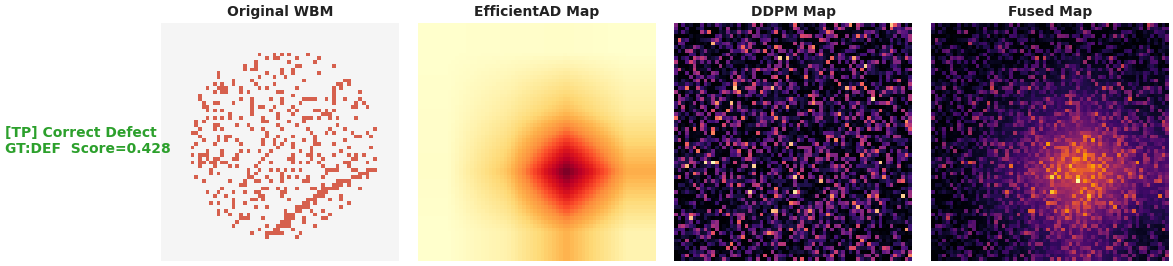

✅ Figure saved → 07_spatial_map_tp.png  (600 DPI)


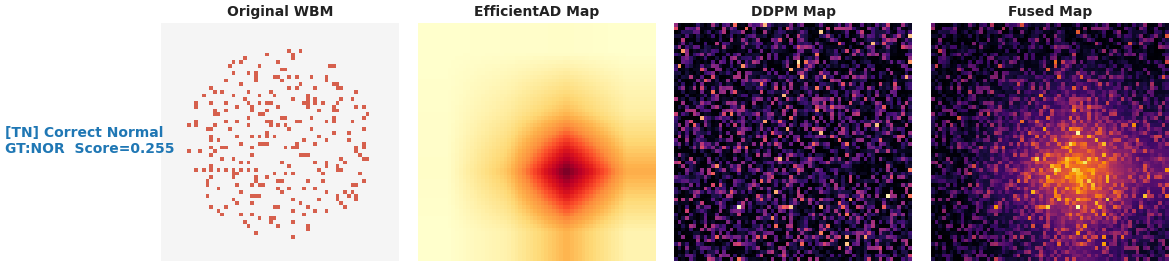

✅ Figure saved → 07_spatial_map_tn.png  (600 DPI)


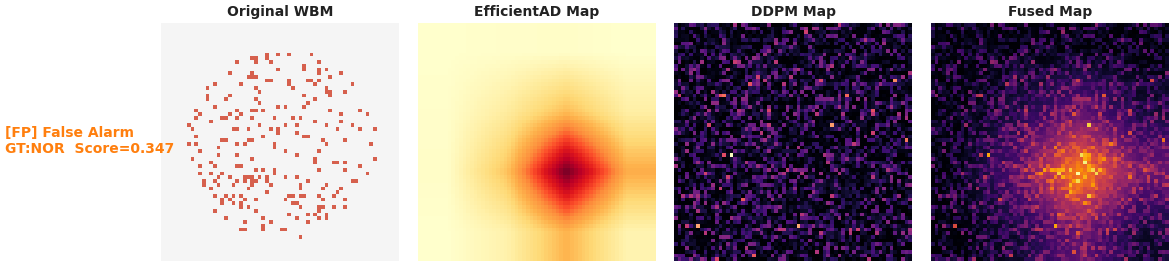

✅ Figure saved → 07_spatial_map_fp.png  (600 DPI)


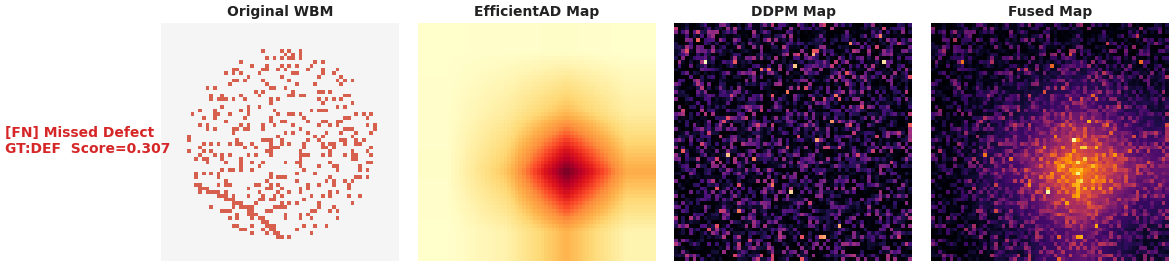

✅ Figure saved → 07_spatial_map_fn.png  (600 DPI)


In [90]:
# ── Figure 7: Spatial Anomaly Map Decomposition (one figure per outcome) ─────
apply_pub_style()

tp_idx = np.where((fused_pred==1) & (y_test==1))[0]
tn_idx = np.where((fused_pred==0) & (y_test==0))[0]
fp_idx = np.where((fused_pred==1) & (y_test==0))[0]
fn_idx = np.where((fused_pred==0) & (y_test==1))[0]

outcome_color = {'TP': CFG.C_FUSION, 'TN': CFG.C_EAD, 'FP': CFG.C_ACCENT, 'FN': CFG.C_DDPM}
outcome_desc  = {'TP': 'Correct Defect', 'TN': 'Correct Normal',
                 'FP': 'False Alarm',    'FN': 'Missed Defect'}
col_titles = ['Original WBM', 'EfficientAD Map', 'DDPM Map', 'Fused Map']
cmaps_     = [WBM_CMAP, ANOM_CMAP, 'magma', 'inferno']

for outcome, grp in [('TP', tp_idx), ('TN', tn_idx), ('FP', fp_idx), ('FN', fn_idx)]:
    if len(grp) == 0:
        print(f"  (no {outcome} examples in this test set — skipped)")
        continue
    si = grp[0]
    raw    = T_test[si].numpy()
    orig   = (raw[2] + 1) / 2
    emap   = norm_map(ead_test_maps[si:si+1])[0]
    dmap   = norm_map(ddpm_test_maps[si:si+1])[0]
    fmap_n = fused_maps[si]
    fmap_n = (fmap_n - fmap_n.min()) / (fmap_n.max() - fmap_n.min() + 1e-8)
    gt_s   = 'DEF' if y_test[si] else 'NOR'
    col_c  = outcome_color[outcome]

    fig, axes = plt.subplots(1, 4, figsize=(13, 3.6), facecolor='white')
    fig.subplots_adjust(wspace=0.08)
    for ax, mdata, cmap_name, ctitle in zip(axes, [orig, emap, dmap, fmap_n], cmaps_, col_titles):
        ax.imshow(mdata, cmap=cmap_name, interpolation='nearest', vmin=0, vmax=1)
        ax.set_title(ctitle, fontsize=10, fontweight='bold')
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_visible(True); spine.set_edgecolor(col_c); spine.set_linewidth(2)
    fig.text(0.005, 0.5, f'[{outcome}] {outcome_desc[outcome]}\nGT:{gt_s}  Score={fused_test[si]:.3f}',
              color=col_c, va='center', fontsize=10, fontweight='bold')

    plt.show()
    save_fig(fig, f'07_spatial_map_{outcome.lower()}.png')


### Publication-Quality Results Table
Test-set metrics with 95% bootstrap confidence intervals for all three model
configurations.



📋 Publication-Quality Results Table (Test Set, 95% CI):
                   Model                  AUROC                     AP                     F1                    MCC                Bal.Acc Params(M)
EfficientAD (Structural) 0.9799 [0.9728–0.9866] 0.9998 [0.9998–0.9999] 0.9604 [0.9582–0.9624] 0.2781 [0.2541–0.3033] 0.9288 [0.9072–0.9473]         —
       DDPM (Generative) 0.9931 [0.9907–0.9952] 0.9999 [0.9999–1.0000] 0.9764 [0.9747–0.9779] 0.3620 [0.3310–0.3920] 0.9538 [0.9353–0.9692]      7.83
   Hybrid Fusion (α=0.5) 0.9985 [0.9978–0.9991] 1.0000 [1.0000–1.0000] 0.9830 [0.9817–0.9843] 0.4321 [0.3996–0.4645] 0.9800 [0.9721–0.9843]         —

✅ CSV saved → 08_results_table.csv


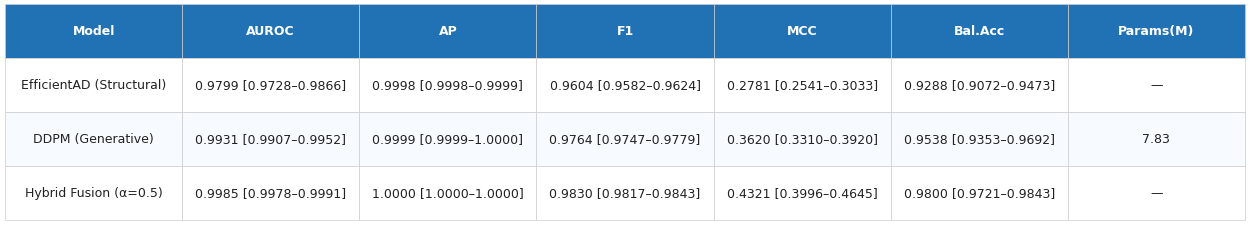

✅ Figure saved → 08_results_table_figure.png  (600 DPI)


'/kaggle/working/output/08_results_table_figure.png'

In [91]:
# ── Cell + Figure 8: Publication-Quality Results Table ───────────────────────
rows = []
for tag, res, pm in [
    ('EfficientAD (Structural)',  res_ead,   None),
    ('DDPM (Generative)',         res_ddpm,  n_params/1e6),
    ('Hybrid Fusion (α=0.5)',     res_fused, None),
]:
    rows.append({
        'Model'    : tag,
        'AUROC'    : f"{res['AUROC']:.4f} [{res['AUROC_lo']:.4f}–{res['AUROC_hi']:.4f}]",
        'AP'       : f"{res['AP']:.4f} [{res['AP_lo']:.4f}–{res['AP_hi']:.4f}]",
        'F1'       : f"{res['F1']:.4f} [{res['F1_lo']:.4f}–{res['F1_hi']:.4f}]",
        'MCC'      : f"{res['MCC']:.4f} [{res['MCC_lo']:.4f}–{res['MCC_hi']:.4f}]",
        'Bal.Acc'  : f"{res['Bal_Acc']:.4f} [{res['Bal_Acc_lo']:.4f}–{res['Bal_Acc_hi']:.4f}]",
        'Params(M)': f"{pm:.2f}" if pm else '—',
    })

df_results = pd.DataFrame(rows)
print("\n📋 Publication-Quality Results Table (Test Set, 95% CI):")
print(df_results.to_string(index=False))
df_results.to_csv(f'{CFG.OUT_DIR}/08_results_table.csv', index=False)
print(f"\n✅ CSV saved → 08_results_table.csv")

apply_pub_style()
fig, ax = plt.subplots(figsize=(16, 2.8), facecolor='white')
ax.axis('off')

table = ax.table(
    cellText=df_results.values, colLabels=df_results.columns,
    cellLoc='center', loc='center', bbox=[0, 0, 1, 1],
)
table.auto_set_font_size(False)
table.set_fontsize(9)

header_color = '#2171b5'
row_colors   = ['#f7fbff', '#ffffff']
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor(header_color)
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor(row_colors[r % 2])
        cell.set_text_props(color='#222222')
    cell.set_edgecolor('#cccccc')
    cell.set_linewidth(0.5)

plt.show()
save_fig(fig, '08_results_table_figure.png')


---
#  Ablation Study




In [92]:
# ── Cell: Ablation A — Fusion Weight α Sweep ─────────────────────────────────
print("🔄 Ablation A: sweeping fusion weight α …")

alpha_rows = []
for a in CFG.ALPHA_SWEEP:
    fv = a * ead_val_scores + (1 - a) * ddpm_val_scores
    fpr_a, tpr_a, thr_a = roc_curve(y_val, fv)
    thr_opt = thr_a[np.argmax(tpr_a - fpr_a)]

    ft = a * ead_test_scores + (1 - a) * ddpm_test_scores
    pred_a = (ft >= thr_opt).astype(int)

    alpha_rows.append({
        'alpha': a,
        'AUROC': roc_auc_score(y_test, ft),
        'AP'   : average_precision_score(y_test, ft),
        'F1'   : f1_score(y_test, pred_a),
    })

df_alpha = pd.DataFrame(alpha_rows)
best_row = df_alpha.loc[df_alpha['AUROC'].idxmax()]
print(df_alpha.to_string(index=False))
print(f"\n✅ Best α by AUROC: {best_row['alpha']:.2f}  "
      f"(AUROC={best_row['AUROC']:.4f} vs. default α=0.5 AUROC={fused_auroc:.4f})")


🔄 Ablation A: sweeping fusion weight α …
 alpha    AUROC       AP       F1
   0.0 0.993113 0.999943 0.976450
   0.1 0.995580 0.999964 0.982300
   0.2 0.997179 0.999977 0.978756
   0.3 0.998044 0.999984 0.985529
   0.4 0.998467 0.999988 0.987279
   0.5 0.998538 0.999988 0.983022
   0.6 0.998044 0.999984 0.985169
   0.7 0.996418 0.999971 0.982941
   0.8 0.993029 0.999942 0.978366
   0.9 0.987547 0.999895 0.963817
   1.0 0.979945 0.999827 0.960364

✅ Best α by AUROC: 0.50  (AUROC=0.9985 vs. default α=0.5 AUROC=0.9985)


### Figure 9 — Fusion Weight (α) Sensitivity
AUROC, Average Precision, and F1 as a function of the fusion weight α
(α=1 ≡ EfficientAD only, α=0 ≡ DDPM only). The dashed line marks the default α=0.5.


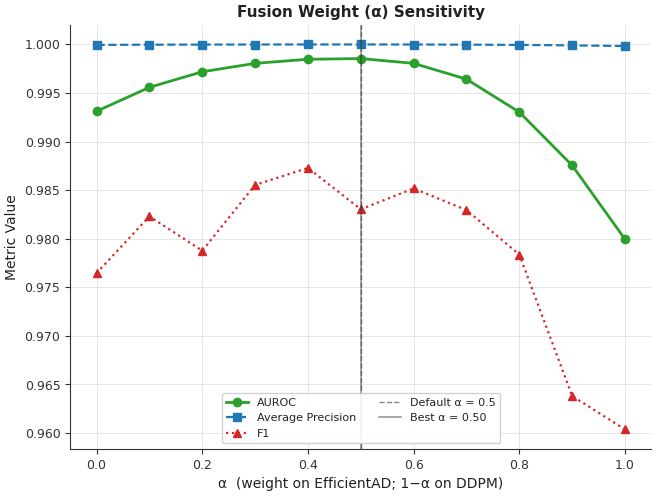

✅ Figure saved → 09_alpha_sensitivity.png  (600 DPI)


'/kaggle/working/output/09_alpha_sensitivity.png'

In [93]:
# ── Figure 9: Fusion Weight Sensitivity Curve ─────────────────────────────────
apply_pub_style()
fig, ax = plt.subplots(figsize=(7.5, 5.5), facecolor='white')

ax.plot(df_alpha['alpha'], df_alpha['AUROC'], marker='o', color=CFG.C_FUSION,
        linewidth=2.0, label='AUROC')
ax.plot(df_alpha['alpha'], df_alpha['AP'], marker='s', color=CFG.C_EAD,
        linewidth=1.6, linestyle='--', label='Average Precision')
ax.plot(df_alpha['alpha'], df_alpha['F1'], marker='^', color=CFG.C_DDPM,
        linewidth=1.6, linestyle=':', label='F1')
ax.axvline(0.5, color='#555555', linewidth=1.0, linestyle='--', alpha=0.7,
           label='Default α = 0.5')
ax.axvline(best_row['alpha'], color='#333333', linewidth=1.2, linestyle='-', alpha=0.5,
           label=f"Best α = {best_row['alpha']:.2f}")
ax.set_title('Fusion Weight (α) Sensitivity', fontweight='bold')
ax.set_xlabel('α  (weight on EfficientAD; 1−α on DDPM)')
ax.set_ylabel('Metric Value')
ax.legend(loc='lower center', fontsize=8, ncol=2)

plt.show()
save_fig(fig, '09_alpha_sensitivity.png')


In [ ]:
# ── Cell: Ablation B — DDPM Reconstruction-Timestep (t*) Sweep ───────────────
print("🔄 Ablation B: sweeping DDPM reconstruction timestep t* …")
_sweep_ddim_steps = min(30, CFG.DDPM_DDIM_STEPS)   # lighter-weight for the sweep

tstar_rows = []
for t_star in CFG.RECON_T_SWEEP:
    _, val_sc  = compute_ddpm_anomaly_scores(val_loader,  t_star=t_star, ddim_steps=_sweep_ddim_steps)
    _, test_sc = compute_ddpm_anomaly_scores(test_loader, t_star=t_star, ddim_steps=_sweep_ddim_steps)

    vm = (y_val == 0)
    lo_t = np.percentile(val_sc[vm], 1)
    hi_t = np.percentile(val_sc[~vm] if (~vm).any() else val_sc, 99)
    norm_test_sc = np.clip((test_sc - lo_t) / (hi_t - lo_t + 1e-8), 0, 1)

    tstar_rows.append({
        't_star': t_star,
        'AUROC' : roc_auc_score(y_test, norm_test_sc),
        'AP'    : average_precision_score(y_test, norm_test_sc),
    })

df_tstar = pd.DataFrame(tstar_rows)
print(df_tstar.to_string(index=False))
best_t = df_tstar.loc[df_tstar['AUROC'].idxmax(), 't_star']
print(f"\n✅ Best t* by AUROC: {best_t}  (chosen operating point in this notebook: {CFG.DDPM_RECON_T})")


🔄 Ablation B: sweeping DDPM reconstruction timestep t* …


### Figure 10 — DDPM Reconstruction-Timestep (t\*) Sensitivity
Higher t\* injects more noise before reconstruction, which increases sensitivity
to subtle defects but risks losing legitimate structure. This sweep justifies the
chosen operating point.


In [ ]:
# ── Figure 10: DDPM Reconstruction-Timestep Sensitivity ──────────────────────
apply_pub_style()
fig, ax = plt.subplots(figsize=(7, 5.5), facecolor='white')

ax.plot(df_tstar['t_star'], df_tstar['AUROC'], marker='o', color=CFG.C_DDPM,
        linewidth=2.0, label='AUROC')
ax.plot(df_tstar['t_star'], df_tstar['AP'], marker='s', color=CFG.C_ACCENT,
        linewidth=1.6, linestyle='--', label='Average Precision')
ax.axvline(CFG.DDPM_RECON_T, color='#333333', linewidth=1.2, linestyle='-', alpha=0.6,
           label=f'Chosen t* = {CFG.DDPM_RECON_T}')
ax.set_title('DDPM Reconstruction Timestep (t*) Sensitivity', fontweight='bold')
ax.set_xlabel('Reconstruction timestep t*')
ax.set_ylabel('Metric Value')
ax.legend(loc='best', fontsize=9)

plt.show()
save_fig(fig, '10_recon_timestep_sensitivity.png')


In [ ]:
# ── Cell: Ablation C — Component Contribution ────────────────────────────────
# "What does each module contribute?" — EfficientAD alone, DDPM alone, and the
# full hybrid fusion, using the metrics already computed above.
print("📊 Component Contribution (Ablation):")
component_rows = [
    {'Configuration': 'EfficientAD only (w/o DDPM)', 'AUROC': ead_auroc,   'AP': ead_ap,   'F1': ead_f1},
    {'Configuration': 'DDPM only (w/o EfficientAD)',  'AUROC': ddpm_auroc,  'AP': ddpm_ap,  'F1': ddpm_f1},
    {'Configuration': 'Full Hybrid Fusion',            'AUROC': fused_auroc, 'AP': fused_ap, 'F1': fused_f1},
]
df_components = pd.DataFrame(component_rows)
print(df_components.to_string(index=False))


### Figure 11 — Component-Contribution Ablation
Each module's standalone performance versus the full hybrid fusion.


In [ ]:
# ── Figure 11: Component-Contribution Bar Chart ──────────────────────────────
apply_pub_style()
labels = ['EfficientAD\n(only)', 'DDPM\n(only)', 'Hybrid\nFusion']
colors = [CFG.C_EAD, CFG.C_DDPM, CFG.C_FUSION]

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), facecolor='white')
fig.subplots_adjust(wspace=0.30)

for ax, col, ylabel, title in [
    (axes[0], 'AUROC', 'AUROC',            'AUROC by Configuration'),
    (axes[1], 'AP',    'Average Precision', 'AP by Configuration'),
]:
    vals = df_components[col].values
    bars = ax.bar(labels, vals, color=colors, edgecolor='white', linewidth=0.5, width=0.55)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(max(0, vals.min()*0.94), 1.02)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.show()
save_fig(fig, '11_component_contribution.png')


---
# Part V — Feature-Space Analysis

A 2D t-SNE projection of the EfficientAD student network's pooled features, to
visually check whether normal and defective wafers separate in feature space.


In [ ]:
# ── Cell + Figure 12: t-SNE of EfficientAD Student Features ──────────────────
from sklearn.manifold import TSNE
import inspect as _inspect

print("🔄 Extracting features for t-SNE (500 samples) …")
_tsne_rng = np.random.default_rng(CFG.SEED)
N_TSNE   = min(500, len(y_test))
tsne_idx = _tsne_rng.choice(len(y_test), N_TSNE, replace=False)

student_net.eval()
ead_feats = []
with torch.no_grad():
    for si in range(0, N_TSNE, 64):
        batch = T_test[tsne_idx[si:si+64]].to(DEVICE)
        feat  = student_net(batch)
        feat  = F.adaptive_avg_pool2d(feat, 1).squeeze(-1).squeeze(-1)
        ead_feats.append(feat.cpu().numpy())

ead_feats = np.concatenate(ead_feats, axis=0)
y_tsne    = y_test[tsne_idx]

print(f"   Feature shape: {ead_feats.shape}")
print("🔄 Running t-SNE …")

# Bug fix: `TSNE(n_iter=...)` was deprecated in scikit-learn 1.5 and REMOVED
# entirely in 1.7+ in favour of `max_iter`. Passing `n_iter` on a modern
# sklearn install raises a TypeError and crashes this cell outright. We
# detect which keyword the installed version accepts instead of hard-coding
# either name.
_tsne_iter_kw = 'max_iter' if 'max_iter' in _inspect.signature(TSNE.__init__).parameters else 'n_iter'
_tsne_kwargs = {_tsne_iter_kw: 1000}

tsne_embed = TSNE(n_components=2, perplexity=40, random_state=SEED,
                  learning_rate='auto', **_tsne_kwargs).fit_transform(ead_feats)

apply_pub_style()
fig, ax = plt.subplots(figsize=(7.5, 6.5), facecolor='white')

for lv, color, name in [(0, CFG.C_NORMAL, 'Normal'), (1, CFG.C_DEFECT, 'Defective')]:
    mask = (y_tsne == lv)
    ax.scatter(tsne_embed[mask, 0], tsne_embed[mask, 1],
               c=color, s=18, alpha=0.75, edgecolors='none',
               label=f'{name} (n={mask.sum()})')

ax.set_title('t-SNE of EfficientAD Student Features (N=500)', fontweight='bold', pad=10)
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(loc='best', fontsize=9)

plt.show()
save_fig(fig, '12_tsne_features.png')


---
# Final Summary


In [ ]:
# ── Cell: Final Summary ───────────────────────────────────────────────────────
print("=" * 65)
print("  HYBRID EFFICIENTAD + DDPM FRAMEWORK — FINAL SUMMARY")
print("=" * 65)
print(f"\n  Dataset    : WM-38K  ({N:,} wafers, 38 classes, {CFG.IMG_SIZE}×{CFG.IMG_SIZE} px)")
print(f"  Task       : One-class anomaly detection (normal vs defective)")
print(f"  Train set  : {len(X_train):,} normal wafers")
print(f"  Test  set  : {len(X_test):,} wafers "
      f"({y_test.sum():,} def / {(y_test==0).sum():,} nor)\n")

print("  ── MODULE 1: EfficientAD (Structural) ─────────────────")
print(f"     Architecture  : Multi-Scale PDN + ResNet-18 Teacher")
print(f"     Training loss : {EAD_HISTORY['loss'][-1]:.5f}")
print(f"     AUROC (test)  : {ead_auroc:.4f}")
print(f"     F1            : {ead_f1:.4f}  |  MCC: {ead_mcc:.4f}")

print("\n  ── MODULE 2: DDPM (Generative) ─────────────────────────")
print(f"     Architecture  : U-Net ε-predictor, cosine schedule, EMA")
print(f"     Parameters    : {n_params/1e6:.2f} M")
print(f"     Epochs        : {CFG.DDPM_EPOCHS}")
print(f"     Training loss : {DDPM_HISTORY['loss'][-1]:.5f}")
print(f"     Sampling rate : {sampling_rate:.2f} it/s")
print(f"     AUROC (test)  : {ddpm_auroc:.4f}")
print(f"     F1            : {ddpm_f1:.4f}  |  MCC: {ddpm_mcc:.4f}")

print("\n  ── FUSION: Hybrid Score (α=0.5) ─────────────────────────")
print(f"     AUROC (test)  : {fused_auroc:.4f}")
print(f"     AP (test)     : {fused_ap:.4f}")
print(f"     F1            : {fused_f1:.4f}")
print(f"     MCC           : {fused_mcc:.4f}")
print(f"     Balanced Acc  : {fused_bal:.4f}")

print("\n  ── ABLATION HIGHLIGHTS ──────────────────────────────────")
print(f"     Best α (AUROC)        : {best_row['alpha']:.2f}  (AUROC={best_row['AUROC']:.4f})")
print(f"     Best t* (AUROC)       : {best_t}")

print("\n  ── SAVED FIGURES ────────────────────────────────────────")
import glob
for f in sorted(glob.glob(f'{CFG.OUT_DIR}/*.png')) + sorted(glob.glob(f'{CFG.OUT_DIR}/*.csv')):
    print(f"     {os.path.basename(f)}")

print(f"\n✅ All outputs saved to: {CFG.OUT_DIR}")
print("=" * 65)
